# Köppel–Martin Case 1: conservative stream-function reconstruction and NLR

This notebook uses the sealed-tip nonconforming CG–LMDFM solve, one Option-A
stream-function network, batched Deng NLR, the corrected fracture-aware audit,
and a common vertex-centred dual transport grid for CG, NLR, PINN, and MRST/EDFM.

The PINN loss contains only integrated dual-face and fixed-grid pointwise CG
data; horizontal physical-boundary faces are excluded because they conflict
with the prescribed streamline trace. Conservation, the multiplier jump, and
top/bottom no-flow for the PINN are imposed by the field architecture, with no
penalty terms. CG and NLR retain their weak/discrete boundary behavior, while
left/right fluxes remain unconstrained for every reconstruction.

In [15]:
from mpi4py import MPI
from petsc4py import PETSc
import pathlib
import time
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from matplotlib.colors import LogNorm
import ufl
import basix.ufl
import torch
import torch.nn as nn
from tqdm.auto import tqdm

from dolfinx import fem, geometry, mesh

comm = MPI.COMM_WORLD
rank = comm.rank
if comm.size != 1:
    raise RuntimeError('This manual point-trace assembly notebook is serial; run it with one MPI rank.')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(1729)
np.random.seed(1729)

REF = 5  # n_bulk = 64; transport uses the 65x65 vertex-centred dual grid
RUN_CONVERGENCE = False
ORDER = 1

K_M_VALUE = 1.0
K_F_VALUE = 10.0

# Koppel-Martin case 1 geometry, with homogeneous-Neumann no-flow fracture tips.
FRAC_A = np.array([0.25, 0.0], dtype=float)
FRAC_B = np.array([0.75, 1.0], dtype=float)
TIP_FRAC = 0.05


import json
import sys
if str(pathlib.Path.cwd()) not in sys.path:
    sys.path.insert(0, str(pathlib.Path.cwd()))
import fracture_hardcurl_common as hc

SEED = 1729
OUTDIR = pathlib.Path("result_km_case1_hardcurl_nlr")
OUTDIR.mkdir(exist_ok=True)
torch.set_default_dtype(torch.float64)
print("output directory:", OUTDIR.resolve())


output directory: /home/muchamad/PhD/fenicsx/code/fracture problem/result_km_case1_hardcurl_nlr


## Stage 1 — sealed-tip CG–LMDFM solve


In [16]:
def unit(v):
    v = np.asarray(v, dtype=float)
    nrm = np.linalg.norm(v)
    if nrm == 0.0:
        raise ValueError("zero-length vector")
    return v / nrm

tau_np = unit(FRAC_B - FRAC_A)
normal_np = np.array([-tau_np[1], tau_np[0]], dtype=float)
L_gamma = float(np.linalg.norm(FRAC_B - FRAC_A))

_G3 = np.array([0.5 - 0.5 * np.sqrt(3.0 / 5.0), 0.5, 0.5 + 0.5 * np.sqrt(3.0 / 5.0)], dtype=float)
_W3 = np.array([5.0 / 18.0, 4.0 / 9.0, 5.0 / 18.0], dtype=float)
_G3_SYM = np.array([-np.sqrt(3.0 / 5.0), 0.0, np.sqrt(3.0 / 5.0)], dtype=float)
_W3_SYM = np.array([5.0 / 9.0, 8.0 / 9.0, 5.0 / 9.0], dtype=float)


def real_points_np(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    return FRAC_A[None, :] + s[:, None] * tau_np[None, :]


def signed_distance_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ normal_np


def s_coord_np(points):
    return (np.asarray(points, dtype=float)[:, :2] - FRAC_A) @ tau_np


def estimate_bulk_h(omega):
    coords = omega.geometry.x

    def min_positive_spacing(values):
        vals = np.unique(np.round(np.sort(values), 14))
        diffs = np.diff(vals)
        diffs = diffs[diffs > 1.0e-12]
        return float(diffs.min()) if diffs.size else np.inf

    return min(min_positive_spacing(coords[:, 0]), min_positive_spacing(coords[:, 1]))


def make_line_mesh_from_s_nodes(s_nodes):
    s_nodes = np.asarray(s_nodes, dtype=float)
    nodes = real_points_np(s_nodes)
    n_cells = len(s_nodes) - 1
    cells = np.column_stack([np.arange(n_cells), np.arange(1, n_cells + 1)]).astype(np.int64)
    coord_el = ufl.Mesh(basix.ufl.element("Lagrange", basix.CellType.interval, 1, shape=(2,)))
    gamma_mesh = mesh.create_mesh(comm, cells, coord_el, nodes)
    return gamma_mesh, float(np.max(np.diff(s_nodes))), int(n_cells)


def make_fracture_pressure_mesh(h):
    # Fracture pressure remains P1 on a relatively fine independent mesh.
    h_gamma_target = 0.5 * h
    n_gamma = max(1, int(np.ceil(L_gamma / h_gamma_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_gamma + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_multiplier_mesh(h):
    # Koppel-Martin case-1 setting for P0 multipliers: h_lambda approx 2h.
    h_lambda_target = 2.0 * h
    n_lambda = max(1, int(round(L_gamma / h_lambda_target)))
    s_nodes = np.linspace(0.0, L_gamma, n_lambda + 1)
    return make_line_mesh_from_s_nodes(s_nodes)


def make_nonconforming_meshes(ref):
    n_bulk = 2 ** (ref + 1)
    omega = mesh.create_unit_square(comm, n_bulk, n_bulk, cell_type=mesh.CellType.quadrilateral)
    h = estimate_bulk_h(omega)
    gamma, h_gamma, n_gamma = make_fracture_pressure_mesh(h)
    gamma_l, h_lambda, n_lambda = make_multiplier_mesh(h)
    return omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda


def quad_points_weights():
    pts, weights = [], []
    for i, xi in enumerate(_G3):
        for j, eta in enumerate(_G3):
            pts.append([xi, eta])
            weights.append(_W3[i] * _W3[j])
    return np.asarray(pts, dtype=float), np.asarray(weights, dtype=float)


def _space_ndofs(V):
    return int(V.dofmap.index_map.size_global * V.dofmap.index_map_bs)


def polygon_signed_area(poly):
    x = poly[:, 0]
    y = poly[:, 1]
    return 0.5 * np.sum(x * np.roll(y, -1) - np.roll(x, -1) * y)


def order_polygon_vertices(pts):
    pts = np.asarray(pts, dtype=float)
    ctr = pts.mean(axis=0)
    ang = np.arctan2(pts[:, 1] - ctr[1], pts[:, 0] - ctr[0])
    poly = pts[np.argsort(ang)]
    if polygon_signed_area(poly) < 0:
        poly = poly[::-1]
    return poly


def build_bulk_cell_data(omega, V_m, n_bulk):
    tdim = omega.topology.dim
    omega.topology.create_connectivity(tdim, 0)
    c2v = omega.topology.connectivity(tdim, 0)
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    geom = omega.geometry.x[:, :2]
    h = 1.0 / n_bulk
    cells = []
    lookup = {}
    num_cells = omega.topology.index_map(tdim).size_local
    for ci in range(num_cells):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        poly = order_polygon_vertices(geom[verts])
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        dofs = np.asarray(V_m.dofmap.cell_dofs(ci), dtype=np.int32)
        cell = {
            "cell_id": int(ci),
            "dofs": dofs,
            "dof_xy": dof_coords[dofs],
            "poly": poly,
            "x0": float(x0),
            "x1": float(x1),
            "y0": float(y0),
            "y1": float(y1),
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
        }
        cells.append(cell)
        ix = int(round(x0 / h))
        iy = int(round(y0 / h))
        lookup[(ix, iy)] = int(ci)
    return {"cells": cells, "lookup": lookup, "n_bulk": int(n_bulk), "h": float(h)}


def locate_bulk_cell_xy(pt, bulk_data):
    x, y = np.asarray(pt, dtype=float)[:2]
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    tol = 1e-12
    ix = n - 1 if x >= 1.0 - tol else int(np.floor(max(x, 0.0) / h))
    iy = n - 1 if y >= 1.0 - tol else int(np.floor(max(y, 0.0) / h))
    ix = min(max(ix, 0), n - 1)
    iy = min(max(iy, 0), n - 1)
    return bulk_data["cells"][bulk_data["lookup"][(ix, iy)]]


def q1_values_grads_on_cell(cell, points):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    x = pts[:, 0]
    y = pts[:, 1]
    x0, x1, y0, y1 = cell["x0"], cell["x1"], cell["y0"], cell["y1"]
    hx, hy = cell["hx"], cell["hy"]
    vals = np.zeros((pts.shape[0], len(cell["dofs"])), dtype=float)
    grads = np.zeros((pts.shape[0], len(cell["dofs"]), 2), dtype=float)
    xmid = 0.5 * (x0 + x1)
    ymid = 0.5 * (y0 + y1)
    for a, xy in enumerate(cell["dof_xy"]):
        if xy[0] < xmid:
            px = (x1 - x) / hx
            dpx = np.full_like(x, -1.0 / hx)
        else:
            px = (x - x0) / hx
            dpx = np.full_like(x, 1.0 / hx)
        if xy[1] < ymid:
            py = (y1 - y) / hy
            dpy = np.full_like(y, -1.0 / hy)
        else:
            py = (y - y0) / hy
            dpy = np.full_like(y, 1.0 / hy)
        vals[:, a] = px * py
        grads[:, a, 0] = dpx * py
        grads[:, a, 1] = px * dpy
    return vals, grads


def bulk_breakpoints_on_segment(xa, xb, bulk_data, tol=1e-12):
    xa = np.asarray(xa, dtype=float)
    xb = np.asarray(xb, dtype=float)
    d = xb - xa
    n = bulk_data["n_bulk"]
    h = bulk_data["h"]
    out = [0.0, 1.0]
    if abs(d[0]) > tol:
        lo, hi = sorted([xa[0], xb[0]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[0]) / d[0]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    if abs(d[1]) > tol:
        lo, hi = sorted([xa[1], xb[1]])
        k0 = max(1, int(np.floor(lo / h)) + 1)
        k1 = min(n - 1, int(np.ceil(hi / h)))
        for k in range(k0, k1 + 1):
            r = (k * h - xa[1]) / d[1]
            if tol < r < 1.0 - tol:
                out.append(float(r))
    return np.asarray(sorted(set(np.round(out, 14))), dtype=float)


In [17]:
def assemble_bulk_stiffness(A, bulk_data):
    qp, qw = quad_points_weights()
    for cell in bulk_data["cells"]:
        x_phys = np.column_stack([
            cell["x0"] + qp[:, 0] * cell["hx"],
            cell["y0"] + qp[:, 1] * cell["hy"],
        ])
        _, grads = q1_values_grads_on_cell(cell, x_phys)
        area = cell["hx"] * cell["hy"]
        Ke = K_M_VALUE * area * np.einsum("q,qid,qjd->ij", qw, grads, grads)
        A.setValues(cell["dofs"], cell["dofs"], Ke, addv=PETSc.InsertMode.ADD_VALUES)


def build_fracture_pressure_data(gamma, V_f):
    coords_f = V_f.tabulate_dof_coordinates()[:, :2]
    cells = []
    s_nodes = []
    num_gamma_cells = gamma.topology.index_map(gamma.topology.dim).size_local
    for ci in range(num_gamma_cells):
        fdofs = np.asarray(V_f.dofmap.cell_dofs(ci), dtype=np.int32)
        s = s_coord_np(coords_f[fdofs])
        order = np.argsort(s)
        fdofs = fdofs[order]
        s = s[order]
        cells.append({"dofs": fdofs, "s0": float(s[0]), "s1": float(s[1])})
        s_nodes.extend([float(s[0]), float(s[1])])
    s_nodes = np.array(sorted(set(np.round(s_nodes, 14))), dtype=float)
    starts = np.array([c["s0"] for c in cells], dtype=float)
    order = np.argsort(starts)
    cells = [cells[i] for i in order]
    return {"cells": cells, "s_nodes": s_nodes}


def locate_pressure_cell_s(s, pressure_data, tol=1e-12):
    cells = pressure_data["cells"]
    if s <= cells[0]["s0"] + tol:
        return cells[0]
    if s >= cells[-1]["s1"] - tol:
        return cells[-1]
    starts = np.array([c["s0"] for c in cells], dtype=float)
    idx = int(np.searchsorted(starts, s, side="right") - 1)
    return cells[min(max(idx, 0), len(cells) - 1)]


def p1_line_basis_on_pressure_cell(cell, s):
    ell = cell["s1"] - cell["s0"]
    return np.array([(cell["s1"] - s) / ell, (s - cell["s0"]) / ell], dtype=float)


def line_mesh_cell_s_intervals(domain):
    domain.topology.create_connectivity(domain.topology.dim, 0)
    c2v = domain.topology.connectivity(domain.topology.dim, 0)
    coords = domain.geometry.x[:, :2]
    intervals = []
    for ci in range(domain.topology.index_map(domain.topology.dim).size_local):
        verts = np.asarray(c2v.links(ci), dtype=np.int32)
        s = np.sort(s_coord_np(coords[verts]))
        intervals.append((float(s[0]), float(s[1])))
    return intervals


def s_breakpoints(s0, s1, s_nodes, tol=1e-12):
    inside = s_nodes[(s_nodes > s0 + tol) & (s_nodes < s1 - tol)]
    return np.concatenate(([s0], inside, [s1])).astype(float)


def assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets):
    off_m, off_f, off_l = offsets
    pressure_data = build_fracture_pressure_data(gamma, V_f)

    for cell in pressure_data["cells"]:
        fdofs = cell["dofs"]
        ell = cell["s1"] - cell["s0"]
        Kloc = (K_F_VALUE / ell) * np.array([[1.0, -1.0], [-1.0, 1.0]], dtype=float)
        A.setValues(off_f + fdofs, off_f + fdofs, Kloc, addv=PETSc.InsertMode.ADD_VALUES)

    for ci, (s0, s1) in enumerate(line_mesh_cell_s_intervals(gamma_l)):
        ldofs = np.asarray(V_l.dofmap.cell_dofs(ci), dtype=np.int32)
        xa, xb = real_points_np([s0, s1])
        seg = xb - xa
        ell = float(np.linalg.norm(seg))

        pbreaks = s_breakpoints(s0, s1, pressure_data["s_nodes"])
        for a, b in zip(pbreaks[:-1], pbreaks[1:]):
            if b - a <= 1e-14:
                continue
            pcell = locate_pressure_cell_s(0.5 * (a + b), pressure_data)
            fdofs = pcell["dofs"]
            for q, w in zip(_G3, _W3):
                sq = a + (b - a) * q
                psi = p1_line_basis_on_pressure_cell(pcell, sq)
                weight = (b - a) * w
                A.setValues(off_f + fdofs, off_l + ldofs, (weight * psi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, off_f + fdofs, (-weight * psi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)

        breaks = bulk_breakpoints_on_segment(xa, xb, bulk_data)
        for r0, r1 in zip(breaks[:-1], breaks[1:]):
            if r1 - r0 <= 1e-14:
                continue
            mid = xa + 0.5 * (r0 + r1) * seg
            bulk_cell = locate_bulk_cell_xy(mid, bulk_data)
            mdofs = bulk_cell["dofs"]
            for q, w in zip(_G3, _W3):
                r = r0 + (r1 - r0) * q
                xq = xa + r * seg
                phi = q1_values_grads_on_cell(bulk_cell, xq[None, :])[0][0]
                weight = ell * (r1 - r0) * w
                A.setValues(mdofs, off_l + ldofs, (-weight * phi).reshape(-1, 1), addv=PETSc.InsertMode.ADD_VALUES)
                A.setValues(off_l + ldofs, mdofs, (weight * phi).reshape(1, -1), addv=PETSc.InsertMode.ADD_VALUES)


def apply_pressure_bcs(A, b, V_m, V_f, offsets):
    off_m, off_f, off_l = offsets
    coords_m = V_m.tabulate_dof_coordinates()[:, :2]
    tol = 1e-12

    left = np.where(np.isclose(coords_m[:, 0], 0.0, atol=tol))[0].astype(np.int32)
    right = np.where(np.isclose(coords_m[:, 0], 1.0, atol=tol))[0].astype(np.int32)

    # Matrix pressure is Dirichlet on x=0 and x=1.  The fracture pressure
    # endpoints are left unconstrained, so the natural boundary condition on
    # Gamma is homogeneous Neumann (no fracture-tip throughflow).
    bc_idx = np.concatenate([off_m + left, off_m + right]).astype(np.int32)
    bc_vals = np.concatenate([
        np.full(len(left), 1.0),
        np.full(len(right), 4.0),
    ]).astype(float)

    x_bc = A.createVecRight()
    x_bc.set(0.0)
    x_bc.setValues(bc_idx, bc_vals)
    x_bc.assemble()
    A.zeroRowsColumns(bc_idx, diag=1.0, x=x_bc, b=b)
    return bc_idx, bc_vals

def solve_petsc_lu(A, b, prefix):
    x = A.createVecRight()
    x.set(0.0)
    last_error = None
    for factor_solver in ("mumps", None):
        try:
            ksp = PETSc.KSP().create(comm)
            ksp.setOptionsPrefix(prefix)
            ksp.setOperators(A)
            ksp.setType(PETSc.KSP.Type.PREONLY)
            pc = ksp.getPC()
            pc.setType(PETSc.PC.Type.LU)
            if factor_solver is not None:
                pc.setFactorSolverType(factor_solver)
            ksp.setFromOptions()
            ksp.solve(b, x)
            reason = ksp.getConvergedReason()
            if reason < 0:
                raise RuntimeError(f"PETSc KSP failed with reason {reason}")
            return x, factor_solver or "petsc-lu"
        except Exception as exc:
            last_error = exc
            if factor_solver is None:
                raise
    raise RuntimeError("LU solve failed") from last_error


def solve_lcg_koppel_martin(ref=REF, order=ORDER, verbose=False):
    if order != 1:
        raise ValueError("The manual point-trace assembly is implemented for Q1/P1/P0 only.")
    omega, gamma, gamma_l, h, h_gamma, h_lambda, n_bulk, n_gamma, n_lambda = make_nonconforming_meshes(ref)
    V_m = fem.functionspace(omega, ("Lagrange", 1))
    V_f = fem.functionspace(gamma, ("Lagrange", 1))
    V_l = fem.functionspace(gamma_l, ("DG", 0))

    n_m = _space_ndofs(V_m)
    n_f = _space_ndofs(V_f)
    n_l = _space_ndofs(V_l)
    offsets = (0, n_m, n_m + n_f)
    n_total = n_m + n_f + n_l

    bulk_data = build_bulk_cell_data(omega, V_m, n_bulk)
    A = PETSc.Mat().createAIJ((n_total, n_total), nnz=80, comm=comm)
    A.setOption(PETSc.Mat.Option.NEW_NONZERO_ALLOCATION_ERR, False)
    A.setUp()
    assemble_bulk_stiffness(A, bulk_data)
    assemble_fracture_and_trace_blocks(A, gamma, gamma_l, V_f, V_l, bulk_data, offsets)
    A.assemble()

    b = A.createVecRight()
    b.set(0.0)
    b.assemble()
    bc_idx, bc_vals = apply_pressure_bcs(A, b, V_m, V_f, offsets)
    A.assemble()

    x, factor_solver = solve_petsc_lu(A, b, prefix=f"km2d_ref{ref}_")
    arr = x.getArray(readonly=True)

    p_m = fem.Function(V_m, name="p_m")
    p_f = fem.Function(V_f, name="p_gamma")
    lmbd = fem.Function(V_l, name="lambda_h")
    p_m.x.array[:] = arr[offsets[0]:offsets[1]]
    p_f.x.array[:] = arr[offsets[1]:offsets[2]]
    lmbd.x.array[:] = arr[offsets[2]:offsets[2] + n_l]
    p_m.x.scatter_forward()
    p_f.x.scatter_forward()
    lmbd.x.scatter_forward()

    k_m = fem.Constant(omega, np.eye(2, dtype=np.float64))
    k_f = fem.Constant(gamma, K_F_VALUE)
    coords = omega.geometry.x
    xmin, xmax = float(coords[:, 0].min()), float(coords[:, 0].max())
    ymin, ymax = float(coords[:, 1].min()), float(coords[:, 1].max())

    if verbose:
        print(f"PETSc LU factor solver: {factor_solver}")
        print(
            f"n_bulk={n_bulk}, n_gamma={n_gamma}, n_lambda={n_lambda}, "
            f"h={h:.3e}, h_gamma={h_gamma:.3e}, h_lambda={h_lambda:.3e}"
        )
        print(f"dofs: matrix={n_m}, fracture={n_f}, lambda(P0)={n_l}, total={n_total}")

    return {
        "ref": int(ref),
        "omega": omega,
        "gamma": gamma,
        "gamma_l": gamma_l,
        "V_m": V_m,
        "V_f": V_f,
        "V_l": V_l,
        "p_m": p_m,
        "p_f": p_f,
        "lmbd": lmbd,
        "k_m": k_m,
        "k_f": k_f,
        "h": float(h),
        "h_gamma": float(h_gamma),
        "h_lambda": float(h_lambda),
        "n_bulk": int(n_bulk),
        "n_gamma": int(n_gamma),
        "n_lambda": int(n_lambda),
        "bulk_data": bulk_data,
        "bbox": (xmin, xmax, ymin, ymax),
        "bc_idx": bc_idx,
        "bc_vals": bc_vals,
        "ndof_total": int(n_total),
        "factor_solver": factor_solver,
    }


t0 = time.perf_counter()
sol = solve_lcg_koppel_martin(REF, ORDER, verbose=True)
print(f"LCG solve complete in {time.perf_counter() - t0:.2f} s")
print(
    f"ref={sol['ref']} h={sol['h']:.3e} h_gamma={sol['h_gamma']:.3e} "
    f"h_lambda={sol['h_lambda']:.3e} n_gamma={sol['n_gamma']} "
    f"n_lambda={sol['n_lambda']} total dofs={sol['ndof_total']}"
)
omega = sol["omega"]; gamma = sol["gamma"]; gamma_l = sol["gamma_l"]
V_m = sol["V_m"]; V_f = sol["V_f"]; V_l = sol["V_l"]
p_m = sol["p_m"]; p_f = sol["p_f"]; lmbd = sol["lmbd"]; k_m = sol["k_m"]
h = sol["h"]; h_est = h
xmin, xmax, ymin, ymax = sol["bbox"]


PETSc LU factor solver: mumps
n_bulk=64, n_gamma=144, n_lambda=36, h=1.562e-02, h_gamma=7.764e-03, h_lambda=3.106e-02
dofs: matrix=4225, fracture=145, lambda(P0)=36, total=4406
LCG solve complete in 1.29 s
ref=5 h=1.562e-02 h_gamma=7.764e-03 h_lambda=3.106e-02 n_gamma=144 n_lambda=36 total dofs=4406


In [18]:
def edge_length(a, b):
    return float(np.linalg.norm(np.asarray(b, dtype=float) - np.asarray(a, dtype=float)))


def outward_edge_normal(a, b, centroid):
    t = np.asarray(b, dtype=float) - np.asarray(a, dtype=float)
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    mid = 0.5 * (np.asarray(a, dtype=float) + np.asarray(b, dtype=float))
    chosen = n1 if np.dot(n1, mid - centroid) > 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


tdim = omega.topology.dim
gdim = omega.geometry.dim
omega.topology.create_connectivity(tdim, 0)
c2v = omega.topology.connectivity(tdim, 0)
omega_geometry = omega.geometry.x
num_cells = omega.topology.index_map(tdim).size_local
local_cell_vertices = [np.asarray(c2v.links(c), dtype=np.int32) for c in range(num_cells)]

# Actual 2D mesh-cell polygons, ordered counter-clockwise for geometry work.
cell_polys = [order_polygon_vertices(omega_geometry[verts, :2]) for verts in local_cell_vertices]
cell_centroids = np.vstack([poly.mean(axis=0) for poly in cell_polys])
cell_areas = np.asarray([abs(polygon_signed_area(poly)) for poly in cell_polys])


def edge_key(x0, x1, decimals=12):
    a = tuple(np.round(x0, decimals))
    b = tuple(np.round(x1, decimals))
    return tuple(sorted((a, b)))


shadow_edges = []
seen_edges = set()
for poly in cell_polys:
    for j in range(len(poly)):
        key = edge_key(poly[j], poly[(j + 1) % len(poly)])
        if key not in seen_edges:
            seen_edges.add(key)
            shadow_edges.append((poly[j].copy(), poly[(j + 1) % len(poly)].copy()))
print("2D quad cells:", num_cells, "unique edges:", len(shadow_edges))

Wq = fem.functionspace(omega, ("DG", ORDER, (gdim,)))
_q_pts = Wq.element.interpolation_points
q_cg_expr = fem.Expression(-ufl.dot(k_m, ufl.grad(p_m)), _q_pts)
q_cg_fun = fem.Function(Wq, name="q_cg")
q_cg_fun.interpolate(q_cg_expr)


def as_eval_points(points):
    points = np.asarray(points, dtype=float)
    if points.ndim == 1:
        points = points.reshape(1, -1)
    if points.shape[1] == 3:
        return points.copy()
    return np.column_stack([points[:, :2], np.zeros(points.shape[0])])


_BBTREE_CACHE = {}


def _get_bbtree(domain):
    key = id(domain)
    tree = _BBTREE_CACHE.get(key)
    if tree is None:
        tree = geometry.bb_tree(domain, domain.topology.dim)
        _BBTREE_CACHE[key] = tree
    return tree


def eval_fem_function(fun, points, domain=None):
    if domain is None:
        domain = fun.function_space.mesh
    pts3 = as_eval_points(points)
    tree = _get_bbtree(domain)
    candidates = geometry.compute_collisions_points(tree, pts3)
    colliding = geometry.compute_colliding_cells(domain, candidates, pts3)
    valid_ids, valid_points, valid_cells = [], [], []
    for i in range(pts3.shape[0]):
        links = colliding.links(i)
        if len(links) > 0:
            valid_ids.append(i)
            valid_points.append(pts3[i])
            valid_cells.append(links[0])
    if not valid_ids:
        return np.full((pts3.shape[0], 1), np.nan)
    vals = np.asarray(fun.eval(np.asarray(valid_points), np.asarray(valid_cells, dtype=np.int32)))
    if vals.ndim == 1:
        vals = vals.reshape(len(valid_points), -1)
    out = np.full((pts3.shape[0], vals.shape[1]), np.nan)
    out[np.asarray(valid_ids, dtype=int), :] = vals
    return out


def q_cg_numpy(points):
    vals = eval_fem_function(q_cg_fun, points, omega)
    return vals[:, :2]


def f_numpy(points):
    pts = np.asarray(points)
    return np.zeros(pts.reshape(-1, pts.shape[-1]).shape[0], dtype=float)


2D quad cells: 4096 unique edges: 8320


In [19]:
def extend_line_to_bbox(a, tau, bbox, tol=1e-14):
    xmin_b, xmax_b, ymin_b, ymax_b = bbox
    ts = []
    if abs(tau[0]) > tol:
        for xval in [xmin_b, xmax_b]:
            t = (xval - a[0]) / tau[0]
            y = a[1] + t * tau[1]
            if ymin_b - tol <= y <= ymax_b + tol:
                ts.append(t)
    if abs(tau[1]) > tol:
        for yval in [ymin_b, ymax_b]:
            t = (yval - a[1]) / tau[1]
            x = a[0] + t * tau[0]
            if xmin_b - tol <= x <= xmax_b + tol:
                ts.append(t)
    if len(ts) < 2:
        raise RuntimeError("Could not extend fracture line to bounding box")
    return min(ts), max(ts)


t_min, t_max = extend_line_to_bbox(FRAC_A, tau_np, (xmin, xmax, ymin, ymax))
GHOST_START = FRAC_A + t_min * tau_np
GHOST_END = FRAC_A + t_max * tau_np


def ghost_points_np(n_each=160):
    pts = []
    if -t_min > 1e-14:
        s_left = np.linspace(t_min, 0.0, n_each, endpoint=False)
        pts.append(FRAC_A[None, :] + s_left[:, None] * tau_np[None, :])
    if t_max - L_gamma > 1e-14:
        s_right = np.linspace(L_gamma, t_max, n_each, endpoint=True)
        pts.append(FRAC_A[None, :] + s_right[:, None] * tau_np[None, :])
    return np.vstack(pts) if pts else np.zeros((0, 2))


def point_in_convex_polygon(pt, poly, tol=1e-12):
    pt = np.asarray(pt, dtype=float)
    for j in range(len(poly)):
        a = poly[j]
        b = poly[(j + 1) % len(poly)]
        edge = b - a
        cross = edge[0] * (pt[1] - a[1]) - edge[1] * (pt[0] - a[0])
        if cross < -tol:
            return False
    return True


def segment_edge_s_intersection(edge_a, edge_b, tol=1e-12):
    v = edge_b - edge_a
    A = np.column_stack((tau_np, -v))
    det = np.linalg.det(A)
    if abs(det) < tol:
        return None
    rhs = edge_a - FRAC_A
    s, u = np.linalg.solve(A, rhs)
    if -tol <= s <= L_gamma + tol and -tol <= u <= 1.0 + tol:
        return float(np.clip(s, 0.0, L_gamma))
    return None


def fracture_intervals_in_polygon(poly, tol=1e-11):
    candidates = [0.0, L_gamma]
    for j in range(len(poly)):
        s_int = segment_edge_s_intersection(poly[j], poly[(j + 1) % len(poly)])
        if s_int is not None:
            candidates.append(s_int)
    candidates = np.array(sorted(candidates), dtype=float)
    unique = []
    for s in candidates:
        if not unique or abs(s - unique[-1]) > tol:
            unique.append(float(s))
    intervals = []
    for s0, s1 in zip(unique[:-1], unique[1:]):
        if s1 - s0 <= tol:
            continue
        sm = 0.5 * (s0 + s1)
        if point_in_convex_polygon(real_points_np([sm])[0], poly, tol=1e-10):
            intervals.append((s0, s1))
    return intervals


def lambda_raw_on_s(s_query):
    return eval_fem_function(lmbd, real_points_np(s_query), gamma_l).reshape(-1)


def multiplier_s_nodes():
    gamma_l.topology.create_connectivity(gamma_l.topology.dim, 0)
    c2v_l = gamma_l.topology.connectivity(gamma_l.topology.dim, 0)
    coords_l = gamma_l.geometry.x[:, :2]
    vals = []
    for ci in range(gamma_l.topology.index_map(gamma_l.topology.dim).size_local):
        verts = np.asarray(c2v_l.links(ci), dtype=np.int32)
        vals.extend(s_coord_np(coords_l[verts]))
    return np.unique(np.round(np.asarray(vals, dtype=float), 12))


_LAM_S_NODES = multiplier_s_nodes()
_GS2 = np.array([-1.0 / np.sqrt(3.0), 1.0 / np.sqrt(3.0)])


def _split_at_lambda_nodes(s0, s1, tol=1e-12):
    lo, hi = (s0, s1) if s0 <= s1 else (s1, s0)
    inner = _LAM_S_NODES[(_LAM_S_NODES > lo + tol) & (_LAM_S_NODES < hi - tol)]
    knots = np.concatenate(([lo], inner, [hi]))
    return list(zip(knots[:-1], knots[1:]))


def integrate_lambda_interval_raw(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b)
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_raw_on_s(sq))
    return float(total)


EDGE_XI = np.array([0.5 * (1.0 - 1.0 / np.sqrt(3.0)), 0.5 * (1.0 + 1.0 / np.sqrt(3.0))], dtype=float)
EDGE_WI = np.array([0.5, 0.5], dtype=float)


def integrate_flux_polygon(poly):
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            flux += w * np.dot(q_cg_numpy(pt[None, :])[0], n_len)
    return float(flux)


def integrate_cg_flux_cell_local(cell_id, poly=None):
    poly = cell_polys[int(cell_id)] if poly is None else poly
    bulk_cell = sol["bulk_data"]["cells"][int(cell_id)]
    uvals = p_m.x.array[bulk_cell["dofs"]]
    flux = 0.0
    centroid = poly.mean(axis=0)
    for j in range(len(poly)):
        x0 = poly[j]
        x1 = poly[(j + 1) % len(poly)]
        edge = x1 - x0
        n_len = outward_edge_normal(x0, x1, centroid) * edge_length(x0, x1)
        for q, w in zip(EDGE_XI, EDGE_WI):
            pt = x0 + q * edge
            _, grads = q1_values_grads_on_cell(bulk_cell, pt[None, :])
            grad = grads[0].T @ uvals
            flux += w * np.dot(-(K_M_VALUE) * grad, n_len)
    return float(flux)


lambda_h_cell_int_raw = np.zeros(num_cells, dtype=float)
gamma_facet_records = []
for cell_id, poly in enumerate(cell_polys):
    for s0, s1 in fracture_intervals_in_polygon(poly):
        lambda_h_cell_int_raw[cell_id] += integrate_lambda_interval_raw(s0, s1)
        gamma_facet_records.append((int(cell_id), float(s0), float(s1), float(s1 - s0)))

cell_flux_cg = np.array([
    integrate_cg_flux_cell_local(_cid, _poly) for _cid, _poly in enumerate(cell_polys)
], dtype=float)
cell_source = np.zeros(num_cells, dtype=float)

# The manual PETSc system is assembled with the weak-form signs in this notebook,
# so lambda enters the local balance directly as the line source.
LAMBDA_SIGN = 1.0
lambda_h_cell_int = lambda_h_cell_int_raw


def lambda_h_on_s(s_query):
    return LAMBDA_SIGN * lambda_raw_on_s(s_query)


print("fracture-cut cells:", len(np.unique([cid for cid, _, _, _ in gamma_facet_records])))
print("LAMBDA_SIGN:", LAMBDA_SIGN)
print("mean |R_CG| with weak-form lambda sign:", np.mean(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))
print("max  |R_CG| with weak-form lambda sign:", np.max(np.abs(cell_flux_cg - cell_source - lambda_h_cell_int)))


fracture-cut cells: 64
LAMBDA_SIGN: 1.0
mean |R_CG| with weak-form lambda sign: 0.0006252961183024347
max  |R_CG| with weak-form lambda sign: 0.16988673999626194


## CG–LMDFM solution


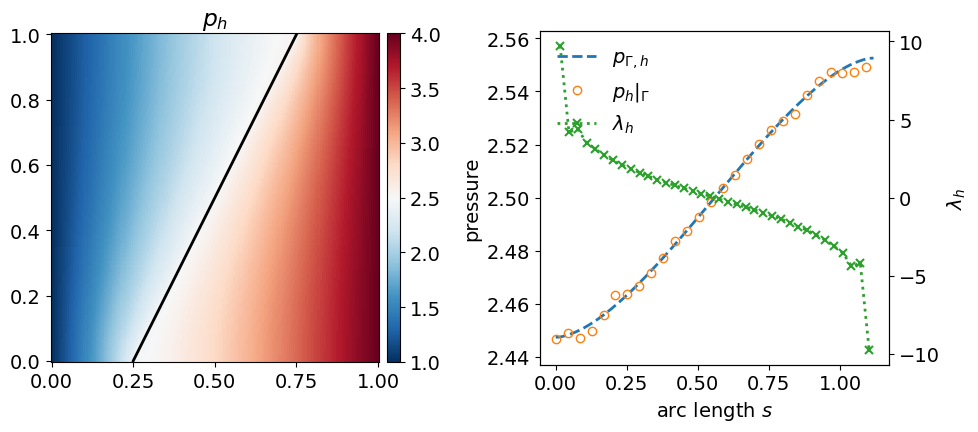

saved: result_km_case1_hardcurl_nlr/fig_km_cg_solution.png


In [20]:
# ============================================================
# Pre-reconstruction visualization of the CG-LCG solution
# ============================================================
from mpl_toolkits.axes_grid1 import make_axes_locatable
plt.rcParams.update({"font.size": 14})

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# (a) matrix pressure p_h over the domain, with the embedded fracture.
_nx = _ny = 160
_xg = np.linspace(xmin, xmax, _nx)
_yg = np.linspace(ymin, ymax, _ny)
_Xg, _Yg = np.meshgrid(_xg, _yg)
_P = eval_fem_function(p_m, np.column_stack([_Xg.ravel(), _Yg.ravel()]), omega).reshape(_ny, _nx)
_pc = axes[0].pcolormesh(_Xg, _Yg, _P, cmap="RdBu_r", shading="auto")
axes[0].plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=2.0)
axes[0].set_aspect("equal")
axes[0].set_title(r"$p_h$")
_div = make_axes_locatable(axes[0])
_cax = _div.append_axes("right", size="4%", pad=0.08)
fig.colorbar(_pc, cax=_cax)

# (b) fracture pressure p_{Gamma,h}, matrix trace p_h|_Gamma, and multiplier lambda_h.
_sf = s_coord_np(V_f.tabulate_dof_coordinates()[:, :2])
_of = np.argsort(_sf)
_s_dense = np.linspace(0.0, L_gamma, 400)
_p_trace = eval_fem_function(p_m, real_points_np(_s_dense), omega).reshape(-1)
_p_gamma_dense = eval_fem_function(p_f, real_points_np(_s_dense), gamma).reshape(-1)
_sl = s_coord_np(V_l.tabulate_dof_coordinates()[:, :2])
_ol = np.argsort(_sl)

# The P0 multiplier enforces one zero pressure-difference moment per panel.
# Since both pressures are continuous, every panel contains at least one
# point where their difference vanishes.  Plot those actual roots instead
# of arbitrary trace samples, which need not coincide pointwise.
def _pressure_trace_difference(s):
    s = np.asarray(s, dtype=float).reshape(-1)
    pts = real_points_np(s)
    return (
        eval_fem_function(p_m, pts, omega).reshape(-1)
        - eval_fem_function(p_f, pts, gamma).reshape(-1)
    )

_coincidence_s = []
for _a, _b in zip(_LAM_S_NODES[:-1], _LAM_S_NODES[1:]):
    _sg = np.linspace(float(_a), float(_b), 257)
    _dg = _pressure_trace_difference(_sg)
    _roots = []
    _exact = np.where(np.abs(_dg) <= 2.0e-12)[0]
    _roots.extend(float(_sg[i]) for i in _exact)
    for _i in np.where(_dg[:-1] * _dg[1:] < 0.0)[0]:
        _lo, _hi = float(_sg[_i]), float(_sg[_i + 1])
        _flo = float(_dg[_i])
        for _ in range(50):
            _mid = 0.5 * (_lo + _hi)
            _fm = float(_pressure_trace_difference([_mid])[0])
            if _flo * _fm <= 0.0:
                _hi = _mid
            else:
                _lo, _flo = _mid, _fm
        _roots.append(0.5 * (_lo + _hi))
    if not _roots:
        _roots = [float(_sg[int(np.argmin(np.abs(_dg)))])]
    _panel_mid = 0.5 * (float(_a) + float(_b))
    _coincidence_s.append(min(_roots, key=lambda value: abs(value - _panel_mid)))
_coincidence_s = np.asarray(_coincidence_s, dtype=float)
_coincidence_p = eval_fem_function(
    p_f, real_points_np(_coincidence_s), gamma
).reshape(-1)
_coincidence_error = float(np.max(np.abs(
    _pressure_trace_difference(_coincidence_s)
)))
if _coincidence_error > 1.0e-9:
    raise RuntimeError(
        f"pressure-coincidence root gate failed: {_coincidence_error:.3e}"
    )

axL = axes[1]
h1, = axL.plot(_sf[_of], p_f.x.array[_of], "--", lw=2.0, color="tab:blue", label=r"$p_{\Gamma,h}$")
axL.plot(_s_dense, _p_trace, "-", lw=0.8, alpha=0.45, color="tab:orange")
h2, = axL.plot(
    _coincidence_s, _coincidence_p, "o", ms=5.5, mfc="none",
    color="tab:orange", label=r"$p_h|_\Gamma=p_{\Gamma,h}$",
)
axL.set_xlabel(r"arc length $s$")
axL.set_ylabel("pressure")

axR = axL.twinx()
h3, = axR.plot(_sl[_ol], lmbd.x.array[_ol], ":x", ms=6, mew=1.5, lw=2.0, color="tab:green", label=r"$\lambda_h$")
axR.set_ylabel(r"$\lambda_h$")

axL.legend(handles=[h1, h2, h3], frameon=False, loc="upper center",
           bbox_to_anchor=(0.5, -0.18), ncol=3, fontsize=12.0)
fig.tight_layout(rect=(0.0, 0.12, 1.0, 1.0))
fig.savefig(OUTDIR / 'fig_km_cg_solution.png', dpi=600, bbox_inches='tight')
plt.show()
print(f"pressure coincidence roots: {len(_coincidence_s)} panels, max mismatch={_coincidence_error:.3e}")
print('saved:', OUTDIR / 'fig_km_cg_solution.png')


## Shared rectangular geometry for the Deng dual grid


In [21]:
# Rectangular Q1 helpers for the 2D Deng post-processing.
if ORDER != 1:
    print("Warning: Deng rectangular local solve is Q1-based; ORDER=1 is recommended.")


def q1_phi(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    return np.stack([
        (1.0 - xi) * (1.0 - eta),
        xi * (1.0 - eta),
        (1.0 - xi) * eta,
        xi * eta,
    ], axis=-1)


def q1_grad_ref(xi_eta):
    xi = np.asarray(xi_eta)[..., 0]
    eta = np.asarray(xi_eta)[..., 1]
    dxi = np.stack([-(1.0 - eta), (1.0 - eta), -eta, eta], axis=-1)
    deta = np.stack([-(1.0 - xi), -xi, (1.0 - xi), xi], axis=-1)
    return np.stack([dxi, deta], axis=-1)


def q1_grad_phys(xi_eta, hx, hy):
    g = q1_grad_ref(xi_eta).astype(float)
    g[..., 0] /= hx
    g[..., 1] /= hy
    return g


def ref_from_phys(cell, x):
    x0, y0 = cell["xy"][0]
    return np.array([(x[0] - x0) / cell["hx"], (x[1] - y0) / cell["hy"]], dtype=float)


def grad_from_coeffs(cell, coeffs, x):
    xi = ref_from_phys(cell, x)
    grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
    return grads.T @ coeffs


def normal_from_C_to_ti(centroid, midpoint, vi):
    t = midpoint - centroid
    n1 = np.array([t[1], -t[0]], dtype=float)
    n2 = -n1
    seg_mid = 0.5 * (centroid + midpoint)
    chosen = n1 if np.dot(n1, vi - seg_mid) < 0.0 else n2
    return chosen / (np.linalg.norm(chosen) + 1e-30)


def prepare_rect_data_from_quad_mesh():
    dof_coords = V_m.tabulate_dof_coordinates()[:, :2]
    dofmap = V_m.dofmap
    pvals = p_m.x.array
    vertex_key_to_id = {}
    vertices_xy = []
    cells = []

    def key_xy(xy):
        return tuple(np.round(np.asarray(xy, dtype=float), 12))

    def get_vid(xy):
        key = key_xy(xy)
        if key not in vertex_key_to_id:
            vertex_key_to_id[key] = len(vertices_xy)
            vertices_xy.append(np.asarray(xy, dtype=float))
        return vertex_key_to_id[key]

    for ci, poly in enumerate(cell_polys):
        x0, y0 = poly.min(axis=0)
        x1, y1 = poly.max(axis=0)
        corners = np.array([[x0, y0], [x1, y0], [x0, y1], [x1, y1]], dtype=float)
        vids = np.array([get_vid(corner) for corner in corners], dtype=np.int32)
        u4 = np.zeros(4, dtype=float)
        cdofs = np.asarray(dofmap.cell_dofs(ci), dtype=np.int32)
        ccoords = dof_coords[cdofs]
        cvals = pvals[cdofs]
        for k, corner in enumerate(corners):
            dist = np.linalg.norm(ccoords - corner[None, :], axis=1)
            u4[k] = float(cvals[np.argmin(dist)])
        cells.append({
            "xy": corners,
            "poly": np.array([[x0, y0], [x1, y0], [x1, y1], [x0, y1]], dtype=float),
            "vids": vids,
            "hx": float(x1 - x0),
            "hy": float(y1 - y0),
            "centroid": np.array([0.5 * (x0 + x1), 0.5 * (y0 + y1)], dtype=float),
            "uvals": u4,
            "cell_id": ci,
        })

    edge_defs = [(0, 1), (1, 3), (3, 2), (2, 0)]
    edge_to_cells = {}
    for ci, cell in enumerate(cells):
        for e, (a, b) in enumerate(edge_defs):
            key = tuple(sorted((int(cell["vids"][a]), int(cell["vids"][b]))))
            edge_to_cells.setdefault(key, []).append((ci, e))
    vertices_xy = np.asarray(vertices_xy, dtype=float)
    vtc = [[] for _ in range(len(vertices_xy))]
    for ci, cell in enumerate(cells):
        for vid in cell["vids"]:
            vtc[int(vid)].append(ci)
    return {
        "cells": cells,
        "vertices_xy": vertices_xy,
        "edge_to_cells": edge_to_cells,
        "vtc": vtc,
        "edge_defs": edge_defs,
        "num_cells": len(cells),
        "num_vertices": len(vertices_xy),
    }


rect = prepare_rect_data_from_quad_mesh()
print("rectangular 2D cells:", rect["num_cells"], "vertices:", rect["num_vertices"])


rectangular 2D cells: 4096 vertices: 4225


## Mandatory geometric, sealed-tip, A0, and A1 gates


In [22]:

# ============================================================
# Option-A common adapter and mandatory construction gates
# ============================================================

def q_cg_cell_local_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int32).reshape(-1)
    out = np.zeros((len(pts), 2), dtype=float)
    for cid in np.unique(cids):
        idx = np.flatnonzero(cids == cid)
        bulk_cell = sol["bulk_data"]["cells"][int(cid)]
        uvals = p_m.x.array[bulk_cell["dofs"]]
        _, grads = q1_values_grads_on_cell(bulk_cell, pts[idx])
        out[idx] = -K_M_VALUE * np.einsum("qad,a->qd", grads, uvals)
    return out


def integrate_hosted_segments(p0, p1, normals, host_cell, order=32, evaluator=None):
    evaluator = q_cg_cell_local_numpy if evaluator is None else evaluator
    xg, wg = hc._gauss01(order)
    d = p1 - p0
    ell = np.linalg.norm(d, axis=1)
    points = (p0[:, None, :] + xg[None, :, None] * d[:, None, :]).reshape(-1, 2)
    cells = np.repeat(np.asarray(host_cell, dtype=np.int32), len(xg))
    values = evaluator(points, cells).reshape(len(p0), len(xg), 2)
    return ell * np.einsum("fqk,fk,q->f", values, normals, wg)


def q_p_f_custom_numpy(points):
    return np.zeros((len(np.asarray(points).reshape(-1, 2)), 2), dtype=float)


def q_cg_common(ctx, gdata, points):
    return q_cg_numpy(points)


def lambda_h_common(ctx, gdata, s):
    return lambda_h_on_s(s)


def f_m_exact_points(points):
    return np.zeros(len(np.asarray(points).reshape(-1, 2)), dtype=float)


def build_km_dual_problem(face_order=32, line_order=12):
    coords = np.asarray(rect["vertices_xy"], dtype=float)
    primal = []
    for cid, cell in enumerate(rect["cells"]):
        # rect local order is [BL, BR, TL, TR]; convert to CCW.
        primal.append((np.asarray(cell["vids"])[[0, 1, 3, 2]], int(cid)))
    coords_check, cv_polys, raw_faces = hc._build_raw_dual_from_subtriangles(coords, primal)
    if not np.allclose(coords_check, coords, rtol=0.0, atol=1.0e-14):
        raise RuntimeError("dual adapter changed the primal vertex ordering")

    pieces, crossings = hc._split_faces_at_fracture(
        raw_faces, FRAC_A, tau_np, normal_np, L_gamma
    )
    p0 = np.vstack([face[0] for face in pieces])
    p1 = np.vstack([face[1] for face in pieces])
    normals = np.vstack([face[2] for face in pieces])
    owner = np.asarray([face[3] for face in pieces], dtype=np.int64)
    neighbor = np.asarray([face[4] for face in pieces], dtype=np.int64)
    host_cell = np.asarray([face[5] for face in pieces], dtype=np.int64)
    side = np.asarray([face[6] for face in pieces], dtype=np.int8)

    lambda_s_nodes = hc._unique_sorted(np.r_[0.0, multiplier_s_nodes(), L_gamma])
    lambda_mid = 0.5 * (lambda_s_nodes[:-1] + lambda_s_nodes[1:])
    lambda_density = np.asarray(lambda_h_on_s(lambda_mid), dtype=float)
    lambda_nodal = np.asarray(lambda_h_on_s(lambda_s_nodes), dtype=float)
    lambda_seg_a = FRAC_A[None, :] + lambda_s_nodes[:-1, None] * tau_np[None, :]
    lambda_seg_b = FRAC_A[None, :] + lambda_s_nodes[1:, None] * tau_np[None, :]

    breaks = hc._unique_sorted(np.r_[lambda_s_nodes, crossings, 0.0, L_gamma])
    density_fn = lambda s: np.asarray(lambda_h_on_s(s), dtype=float)
    src_points, src_weights, _ = hc._common_line_quadrature(
        breaks, FRAC_A, tau_np, density_fn, order=max(4, line_order // 2)
    )
    qpl_face = hc._line_source_face_flux(p0, p1, normals, src_points, src_weights)
    cv_lambda, split_cut, split_touch = hc._distribute_line_quadrature_to_cvs(
        cv_polys, src_points, src_weights, normal_np
    )
    cv_source = np.zeros(len(coords), dtype=float)
    boundary = (
        np.isclose(coords[:, 0], 0.0, atol=2.0e-12)
        | np.isclose(coords[:, 0], 1.0, atol=2.0e-12)
        | np.isclose(coords[:, 1], 0.0, atol=2.0e-12)
        | np.isclose(coords[:, 1], 1.0, atol=2.0e-12)
    )
    cv_class = np.full(len(coords), "interior-away", dtype=object)
    cv_class[split_cut] = "fracture-cut"
    cv_class[split_touch & ~split_cut] = "fracture-adjacent"
    cv_class[boundary] = "boundary"

    cg_face = integrate_hosted_segments(p0, p1, normals, host_cell, order=face_order)
    gdata = {
        "FRAC_A": FRAC_A.copy(), "FRAC_B": FRAC_B.copy(),
        "tau_np": tau_np.copy(), "normal_np": normal_np.copy(),
        "L_gamma": float(L_gamma), "h_est": float(h_est),
        "omega_geometry": coords.copy(), "cell_polys": cell_polys,
        "local_cell_vertices": local_cell_vertices,
    }
    common_ns = {
        "K_M_VALUE": K_M_VALUE, "K_F_VALUE": K_F_VALUE,
        "q_cg_numpy": q_cg_common, "lambda_h_on_s": lambda_h_common,
        "q_p_f_custom_numpy": q_p_f_custom_numpy,
        "f_m_exact_points": f_m_exact_points,
        "exact_q": lambda points: q_cg_numpy(points),
        "has_exact_lambda": False,
        "order": ORDER, "lambda_order": 0,
    }
    return hc.DualProblem(
        variant="km_case1_neumann_tips", ctx={}, gdata=gdata,
        coords=coords, p0=p0, p1=p1, normals=normals,
        owner=owner, neighbor=neighbor, host_cell=host_cell, side=side,
        cv_polys=cv_polys, cv_source=cv_source,
        cv_lambda_exact=cv_lambda.copy(), cv_lambda_h=cv_lambda,
        cv_class=cv_class, lambda_s_nodes=lambda_s_nodes,
        lambda_h_density=lambda_density,
        lambda_h_nodal_density=lambda_nodal,
        lambda_seg_a=lambda_seg_a, lambda_seg_b=lambda_seg_b,
        qpf_face=np.zeros(len(p0)), qpl_exact_face=qpl_face.copy(),
        qpl_h_face=qpl_face, cg_face=cg_face, exact_face=cg_face.copy(),
        curl_sign=hc._curl_endpoint_sign(p0, p1, normals),
        source_quad_exact_points=src_points,
        source_quad_exact_weights=src_weights,
        source_quad_h_points=src_points, source_quad_h_weights=src_weights,
        polynomial_order=ORDER, multiplier_order=0, globals_ns=common_ns,
    )


def gate_mrst_dual_decomposition():
    """64x64 vertex duals must be exact unions of 128x128 MRST cells."""
    h_cg = 1.0 / 64.0
    h_mrst = 1.0 / 128.0
    assert abs(h_cg - 2.0 * h_mrst) <= 1.0e-15
    lines = (np.arange(64, dtype=float) + 0.5) * h_cg
    mrst_lines = (2 * np.arange(64) + 1) * h_mrst
    error = float(np.max(np.abs(lines - mrst_lines)))
    if error > 5.0e-15:
        raise RuntimeError(f"MRST/dual decomposition gate failed: {error:.3e}")
    counts = {"interior": [2, 2], "edge": [1, 2], "corner": [1, 1]}
    print(f"MRST-to-dual geometric gate: PASS, max line error={error:.3e}, unions={counts}")
    return {"passed": True, "max_line_error": error, "union_shapes": counts}


def gate_sealed_tip_exchange(tol=1.0e-10):
    mids = 0.5 * (multiplier_s_nodes()[:-1] + multiplier_s_nodes()[1:])
    widths = np.diff(multiplier_s_nodes())
    integral = float(np.dot(widths, lambda_h_on_s(mids)))
    scale = max(1.0, float(np.dot(widths, np.abs(lambda_h_on_s(mids)))))
    passed = abs(integral) <= tol * scale
    print(
        f"sealed-tip exchange gate: {'PASS' if passed else 'FAIL'}, "
        f"integral_Gamma(lambda_h)={integral:.6e}, tol={tol * scale:.3e}"
    )
    if not passed:
        raise RuntimeError("sealed-tip net exchange does not balance")
    return {"passed": passed, "integral": integral, "tolerance": tol * scale}


def _max_box_offset(point, direction):
    limits = []
    for coordinate, velocity in zip(point, direction):
        if velocity > 0.0:
            limits.append((1.0 - coordinate) / velocity)
        elif velocity < 0.0:
            limits.append((0.0 - coordinate) / velocity)
    return min(value for value in limits if value >= 0.0)


def gate_a0_km_boundary_tips(problem, tol=2.0e-6):
    panel_mid = 0.5 * (
        problem.lambda_s_nodes[:-1] + problem.lambda_s_nodes[1:]
    )
    samples = panel_mid[[0, len(panel_mid) // 2, -1]]
    rows = []
    for s in samples:
        x = FRAC_A + s * tau_np
        eps_max = min(_max_box_offset(x, normal_np), _max_box_offset(x, -normal_np))
        eps_values = np.minimum(
            np.asarray([1.0e-5, 1.0e-6, 1.0e-7, 1.0e-8]),
            0.2 * eps_max,
        )
        eps_values = np.unique(eps_values[eps_values > 0.0])[::-1]
        if len(eps_values) == 0:
            raise RuntimeError("no interior mirrored pair available near a boundary tip")
        density = float(lambda_h_on_s(np.array([s]))[0])
        sequence = []
        for eps in eps_values:
            xp = x + eps * normal_np
            xm = x - eps * normal_np
            if np.any(xp < -1.0e-14) or np.any(xp > 1.0 + 1.0e-14):
                raise RuntimeError("A0 plus point left Omega")
            if np.any(xm < -1.0e-14) or np.any(xm > 1.0 + 1.0e-14):
                raise RuntimeError("A0 minus point left Omega")
            qp = hc.q_p_lambda_p0_numpy(
                xp[None, :], problem.lambda_seg_a, problem.lambda_seg_b,
                problem.lambda_h_density,
            )[0]
            qm = hc.q_p_lambda_p0_numpy(
                xm[None, :], problem.lambda_seg_a, problem.lambda_seg_b,
                problem.lambda_h_density,
            )[0]
            jump = float(np.dot(qp - qm, normal_np))
            rel = abs(jump - density) / max(1.0, abs(density))
            sequence.append({"eps": float(eps), "jump": jump, "relative_error": rel})
        rows.append({"s": float(s), "density": density, "sequence": sequence,
                     "final_relative_error": sequence[-1]["relative_error"]})
    worst = max(row["final_relative_error"] for row in rows)
    passed = worst <= tol
    print(f"Gate A0-KM boundary tips: {'PASS' if passed else 'FAIL'}, worst rel={worst:.3e}")
    for row in rows:
        print(" ", row)
    if not passed:
        raise RuntimeError("Gate A0-KM failed")
    return {"passed": passed, "tolerance": tol, "rows": rows}


mrst_dual_gate = gate_mrst_dual_decomposition()
sealed_tip_gate = gate_sealed_tip_exchange()
problem = build_km_dual_problem()
print("dual CV classes:", {
    name: int(np.count_nonzero(problem.cv_class == name))
    for name in hc.class_names() if name != "source"
})
a0_generic = hc.gate_a0()
a0_km = gate_a0_km_boundary_tips(problem)
a1 = hc.gate_a1(problem)
KM_STAGE1_GATES_COMPLETE = True
print("Stage 1 gates complete.")


MRST-to-dual geometric gate: PASS, max line error=0.000e+00, unions={'interior': [2, 2], 'edge': [1, 2], 'corner': [1, 1]}
sealed-tip exchange gate: PASS, integral_Gamma(lambda_h)=-3.406020e-11, tol=2.561e-10
dual CV classes: {'interior-away': 3874, 'fracture-cut': 95, 'fracture-adjacent': 0, 'boundary': 256}
Gate A0: PASS (tol=1.0e-08)
  normal jump=+1.6999999989177466e+00, density=+1.7000000000000000e+00, relative error=6.366e-10
  tangential jump=+0.000e+00
Gate A0-KM boundary tips: PASS, worst rel=3.296e-07
  {'s': 0.0155282498435, 'density': 9.724884457076453, 'sequence': [{'eps': 1e-05, 'jump': 9.721679553876074, 'relative_error': 0.00032955694378935277}, {'eps': 1e-06, 'jump': 9.724563966713632, 'relative_error': 3.295569877826997e-05}, {'eps': 1e-07, 'jump': 9.724852408040121, 'relative_error': 3.2955698829049718e-06}, {'eps': 1e-08, 'jump': 9.724881252172812, 'relative_error': 3.2955698902114107e-07}], 'final_relative_error': 3.2955698902114107e-07}
  {'s': 0.5745452442185, 'd

## Stage 2 — Option-A canonical training

The trainable potential is multiplied by $y(1-y)$ and added to fixed bottom
and top traces obtained from the analytic cumulative normal flux of the
particular line-source field. Hence each horizontal-boundary subsegment has
zero integrated normal flux by endpoint telescoping. No condition is imposed
on the left or right boundary.

In [23]:

# ============================================================
# Canonical Option-A training with exact horizontal streamline traces
# ============================================================

accepted_lbfgs = []
STAGNATION_WINDOW = 200
STAGNATION_RTOL = 1.0e-6
CHECKPOINT_PATH = OUTDIR / "km_case1_option_a_streamline_bc_v2.pt"


def km_zero_constant_boundary_trace_numpy(x_coordinate, y_boundary):
    source = np.asarray(problem.source_quad_h_points, dtype=float)
    weight = np.asarray(problem.source_quad_h_weights, dtype=float)
    distance = float(y_boundary) - source[:, 1]
    angle = (
        np.arctan((np.asarray(x_coordinate)[:, None] - source[None, :, 0])
                  / distance[None, :])
        - np.arctan((-source[:, 0] / distance))[None, :]
    )
    return angle @ weight / (2.0 * np.pi)


# Horizontal streamline traces are determined up to one constant each. Their
# difference controls total horizontal throughput. Choose the top-minus-bottom
# constant to match the CG total right-boundary flux, without prescribing its
# pointwise distribution.
_g0_p0 = km_zero_constant_boundary_trace_numpy(problem.p0[:, 0], 0.0)
_g1_p0 = km_zero_constant_boundary_trace_numpy(problem.p0[:, 0], 1.0)
_g0_p1 = km_zero_constant_boundary_trace_numpy(problem.p1[:, 0], 0.0)
_g1_p1 = km_zero_constant_boundary_trace_numpy(problem.p1[:, 0], 1.0)
_psi_fixed_p0 = (1.0 - problem.p0[:, 1]) * _g0_p0 + problem.p0[:, 1] * _g1_p0
_psi_fixed_p1 = (1.0 - problem.p1[:, 1]) * _g0_p1 + problem.p1[:, 1] * _g1_p1
_right_face = (
    (problem.neighbor < 0)
    & np.isclose(problem.p0[:, 0], 1.0, atol=2.0e-14)
    & np.isclose(problem.p1[:, 0], 1.0, atol=2.0e-14)
)
_right_fixed_flux = np.sum(
    problem.qpf_face[_right_face] + problem.qpl_h_face[_right_face]
    + problem.curl_sign[_right_face]
    * (_psi_fixed_p1[_right_face] - _psi_fixed_p0[_right_face])
)
_right_constant_coefficient = np.sum(
    problem.curl_sign[_right_face]
    * (problem.p1[_right_face, 1] - problem.p0[_right_face, 1])
)
KM_TOP_TRACE_CONSTANT = float(
    (np.sum(problem.cg_face[_right_face]) - _right_fixed_flux)
    / _right_constant_coefficient
)
print(
    f"streamline trace constant: c_top-c_bottom={KM_TOP_TRACE_CONSTANT:.8e}; "
    f"right total fixed from {_right_fixed_flux:.8e} "
    f"to {np.sum(problem.cg_face[_right_face]):.8e}"
)


class KMStreamlinePsiNet(nn.Module):
    """Single-valued potential with exact q.n=0 traces on y=0 and y=1."""

    def __init__(self, frequencies, width, depth):
        super().__init__()
        self.interior = hc.FourierPsiNet(frequencies, width, depth)
        source = np.asarray(problem.source_quad_h_points, dtype=float)
        weight = np.asarray(problem.source_quad_h_weights, dtype=float)
        self.register_buffer("source_x", torch.as_tensor(source[:, 0], dtype=hc.TORCH_DTYPE))
        self.register_buffer("source_y", torch.as_tensor(source[:, 1], dtype=hc.TORCH_DTYPE))
        self.register_buffer("source_weight", torch.as_tensor(weight, dtype=hc.TORCH_DTYPE))
        self.register_buffer(
            "top_trace_constant",
            torch.as_tensor(KM_TOP_TRACE_CONSTANT, dtype=hc.TORCH_DTYPE),
        )
        self._training_trace_cache = {}

    def boundary_trace(self, x_coordinate, y_boundary):
        # Exact x-antiderivative of the point-source representation used by
        # problem.qpl_h_face. Gauss source nodes lie strictly inside their
        # panels, so y_boundary-source_y is nonzero even at the fracture tips.
        distance = float(y_boundary) - self.source_y
        ratio = (x_coordinate[:, None] - self.source_x[None, :]) / distance[None, :]
        ratio_zero = (-self.source_x / distance)[None, :]
        angle = torch.atan(ratio) - torch.atan(ratio_zero)
        trace = torch.sum(angle * self.source_weight[None, :], dim=1) / (2.0 * torch.pi)
        if float(y_boundary) == 1.0:
            trace = trace + self.top_trace_constant
        return trace

    def _fixed_value(self, x):
        y = x[:, 1]
        g_bottom = self.boundary_trace(x[:, 0], 0.0)
        g_top = self.boundary_trace(x[:, 0], 1.0)
        return (1.0 - y) * g_bottom + y * g_top

    def training_fixed_curl_numpy(self, points):
        """Curl of the fixed boundary blend, evaluated once for pointwise data."""
        points = np.asarray(points, dtype=float).reshape(-1, 2)
        source_x = self.source_x.detach().cpu().numpy()
        source_y = self.source_y.detach().cpu().numpy()
        weight = self.source_weight.detach().cpu().numpy()

        def value_and_dx(y_boundary):
            distance = float(y_boundary) - source_y
            delta = points[:, 0, None] - source_x[None, :]
            angle = (
                np.arctan(delta / distance[None, :])
                - np.arctan((-source_x / distance))[None, :]
            )
            value = angle @ weight / (2.0 * np.pi)
            derivative = (
                (distance[None, :] / (delta * delta + distance[None, :] ** 2))
                @ weight / (2.0 * np.pi)
            )
            return value, derivative

        g0, dg0 = value_and_dx(0.0)
        g1, dg1 = value_and_dx(1.0)
        g1 = g1 + float(self.top_trace_constant.detach().cpu())
        y = points[:, 1]
        return np.column_stack((
            g1 - g0,
            -((1.0 - y) * dg0 + y * dg1),
        ))

    def forward(self, x):
        y = x[:, 1]
        if self.training:
            # The face endpoints and pointwise grid are fixed for every closure.
            # Cache the parameter-free trace values; its curl on the pointwise
            # grid is included once in pointwise_base by run_option_a.
            key = (int(x.data_ptr()), tuple(x.shape), str(x.device), str(x.dtype))
            fixed = self._training_trace_cache.get(key)
            if fixed is None:
                with torch.no_grad():
                    fixed = self._fixed_value(x).detach()
                self._training_trace_cache[key] = fixed
        else:
            # Evaluation needs the true coordinate derivative of the fixed trace.
            fixed = self._fixed_value(x)
        interior_window = y * (1.0 - y)
        return fixed + interior_window * self.interior(x)


def km_model_factory(frequencies, width, depth):
    return KMStreamlinePsiNet(frequencies, width, depth)


horizontal_boundary_face = (
    (problem.neighbor < 0)
    & (
        (np.isclose(problem.p0[:, 1], 0.0, atol=2.0e-14)
         & np.isclose(problem.p1[:, 1], 0.0, atol=2.0e-14))
        | (np.isclose(problem.p0[:, 1], 1.0, atol=2.0e-14)
           & np.isclose(problem.p1[:, 1], 1.0, atol=2.0e-14))
    )
)
training_face_mask = ~horizontal_boundary_face
print(
    "face-loss mask: active=", int(np.count_nonzero(training_face_mask)),
    "excluded horizontal-boundary pieces=", int(np.count_nonzero(horizontal_boundary_face)),
)


def gate_hard_streamline_boundary(tol=2.0e-12):
    if np.max(np.abs(problem.qpf_face[horizontal_boundary_face])) > 1.0e-15:
        raise RuntimeError("KM hard-boundary trace assumes the smooth particular field is zero")
    probe_model = km_model_factory((1, 2, 4, 8), 32, 3).to(dtype=hc.TORCH_DTYPE)
    probe_model.eval()

    # First check every native horizontal boundary face piece.
    ids = np.flatnonzero(horizontal_boundary_face)
    with torch.no_grad():
        psi0 = probe_model(torch.as_tensor(problem.p0[ids], dtype=hc.TORCH_DTYPE)).cpu().numpy()
        psi1 = probe_model(torch.as_tensor(problem.p1[ids], dtype=hc.TORCH_DTYPE)).cpu().numpy()
    native_flux = (
        problem.qpf_face[ids] + problem.qpl_h_face[ids]
        + problem.curl_sign[ids] * (psi1 - psi0)
    )

    # Then check a separate dense family of subsegments, including segments
    # adjacent to the boundary fracture tips. This is independent of the face
    # loss and verifies the cumulative-trace formula segment by segment.
    x_nodes = np.unique(np.r_[
        np.linspace(0.0, 1.0, 257), FRAC_A[0], FRAC_B[0],
        np.asarray([0.249999, 0.250001, 0.749999, 0.750001]),
    ])
    arbitrary = []
    for y_boundary, normal_y in ((0.0, -1.0), (1.0, 1.0)):
        a = np.column_stack((x_nodes[:-1], np.full(len(x_nodes) - 1, y_boundary)))
        b = np.column_stack((x_nodes[1:], np.full(len(x_nodes) - 1, y_boundary)))
        normals = np.column_stack((np.zeros(len(a)), np.full(len(a), normal_y)))
        base_flux = hc._line_source_face_flux(
            a, b, normals, problem.source_quad_h_points, problem.source_quad_h_weights
        )
        with torch.no_grad():
            va = probe_model(torch.as_tensor(a, dtype=hc.TORCH_DTYPE)).cpu().numpy()
            vb = probe_model(torch.as_tensor(b, dtype=hc.TORCH_DTYPE)).cpu().numpy()
        tangent = b - a
        n_right = np.column_stack((tangent[:, 1], -tangent[:, 0]))
        n_right /= np.linalg.norm(tangent, axis=1)[:, None]
        orientation = np.sign(np.einsum("ij,ij->i", normals, n_right))
        arbitrary.append(base_flux + orientation * (vb - va))
    arbitrary_flux = np.concatenate(arbitrary)
    native_max = float(np.max(np.abs(native_flux)))
    arbitrary_max = float(np.max(np.abs(arbitrary_flux)))
    passed = max(native_max, arbitrary_max) <= tol
    print(
        f"hard streamline-boundary gate: {'PASS' if passed else 'FAIL'}, "
        f"native max={native_max:.3e}, dense subsegment max={arbitrary_max:.3e}"
    )
    if not passed:
        raise RuntimeError("hard streamline-boundary trace gate failed")
    return {
        "passed": True, "tolerance": tol,
        "native_face_max_abs_flux": native_max,
        "dense_subsegment_max_abs_flux": arbitrary_max,
        "excluded_face_loss_pieces": int(np.count_nonzero(horizontal_boundary_face)),
        "left_right_boundaries_constrained": False,
    }


hard_streamline_gate = gate_hard_streamline_boundary()


def accepted_step_logger(iteration, model, loss_fn):
    loss = float(loss_fn().detach().cpu())
    accepted_lbfgs.append({"iteration": int(iteration), "loss": loss})
    if iteration == 0 or iteration % 50 == 0:
        print(f"accepted L-BFGS {iteration:4d}: loss={loss:.8e}")
    if iteration < STAGNATION_WINDOW:
        return False
    old = accepted_lbfgs[-1 - STAGNATION_WINDOW]["loss"]
    relative_decrease = (old - loss) / max(abs(old), 1.0e-30)
    if relative_decrease < STAGNATION_RTOL:
        print(
            f"relative stagnation at accepted step {iteration}: "
            f"{relative_decrease:.3e} < {STAGNATION_RTOL:.1e}"
        )
        return True
    return False


if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location="cpu", weights_only=False)
    if (
        int(checkpoint["width"]) != 32 or int(checkpoint["depth"]) != 3
        or tuple(checkpoint["frequencies"]) != (1, 2, 4, 8)
        or int(checkpoint["seed"]) != SEED
        or not bool(checkpoint.get("hard_streamline_bc", False))
        or not np.isclose(
            float(checkpoint.get("top_trace_constant", np.nan)),
            KM_TOP_TRACE_CONSTANT, rtol=0.0, atol=1.0e-14,
        )
    ):
        raise RuntimeError("existing Option-A checkpoint does not match the frozen protocol")
    model = km_model_factory(
        checkpoint["frequencies"], checkpoint["width"], checkpoint["depth"]
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.eval()
    x0 = torch.as_tensor(problem.p0, dtype=hc.TORCH_DTYPE)
    x1 = torch.as_tensor(problem.p1, dtype=hc.TORCH_DTYPE)
    sign = torch.as_tensor(problem.curl_sign, dtype=hc.TORCH_DTYPE)
    with torch.no_grad():
        curl_face = (sign * (model(x1) - model(x0))).cpu().numpy()
    option_a = {
        "model": model,
        "face_flux": problem.qpf_face + problem.qpl_h_face + curl_face,
        "width": checkpoint["width"], "depth": checkpoint["depth"],
        "frequencies": tuple(checkpoint["frequencies"]),
        "seed": checkpoint["seed"], "history": checkpoint["history"],
        "optimization": checkpoint["optimization"],
        "wall_time": checkpoint["wall_time"],
        "particular_lambda_mode": "h",
        "hard_streamline_bc": True,
    }
    accepted_lbfgs = list(checkpoint["accepted_step_history"])
    print("loaded validated Option-A checkpoint:", CHECKPOINT_PATH)
else:
    option_a = hc.run_option_a(
        problem, adam_steps=2000, lbfgs_steps=3000,
        width=32, depth=3, frequencies=(1, 2, 4, 8), lr=2.0e-3,
        seed=SEED, face_weight=1.0, potential_weight=0.0,
        pointwise_weight=1.0, target_mode="cg", particular_lambda_mode="h",
        lbfgs_iteration_callback=accepted_step_logger,
        model_factory=km_model_factory, face_mask=training_face_mask,
    )
    option_a["hard_streamline_bc"] = True

    checkpoint = {
        "state_dict": option_a["model"].state_dict(),
        "width": option_a["width"], "depth": option_a["depth"],
        "frequencies": list(option_a["frequencies"]), "seed": option_a["seed"],
        "history": option_a["history"], "optimization": option_a["optimization"],
        "wall_time": option_a["wall_time"],
        "accepted_step_history": accepted_lbfgs,
        "face_weight": 1.0, "pointwise_weight": 1.0, "potential_weight": 0.0,
        "hard_streamline_bc": True,
        "top_trace_constant": KM_TOP_TRACE_CONSTANT,
        "excluded_horizontal_boundary_face_pieces": int(
            np.count_nonzero(horizontal_boundary_face)
        ),
        "FRAC_A": FRAC_A, "FRAC_B": FRAC_B, "normal": normal_np, "tau": tau_np,
    }
    torch.save(checkpoint, CHECKPOINT_PATH)
    print("saved:", CHECKPOINT_PATH)


streamline trace constant: c_top-c_bottom=-3.37901176e+00; right total fixed from -9.13238185e-02 to -3.47033558e+00
face-loss mask: active= 16704 excluded horizontal-boundary pieces= 256
hard streamline-boundary gate: PASS, native max=4.096e-16, dense subsegment max=4.250e-16
loaded validated Option-A checkpoint: result_km_case1_hardcurl_nlr/km_case1_option_a_streamline_bc_v2.pt


## Stage 3 — Deng nonlinear local reconstruction


In [24]:
def integrate_segment_basis_flux(cell, a, b, n_out):
    seg_len = edge_length(a, b)
    out = np.zeros(4, dtype=float)
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        xi = ref_from_phys(cell, x)
        grads = q1_grad_phys(xi[None, :], cell["hx"], cell["hy"])[0]
        out += w * (-(K_M_VALUE) * (grads @ n_out)) * seg_len
    return out


def local_kgrad_dot_n(cell, coeffs, x, n_out):
    grad = grad_from_coeffs(cell, coeffs, x)
    return float(np.dot(K_M_VALUE * grad, n_out))


def averaged_kgrad_dot_n(rect, ci, edge_key, x, n_out):
    cell = rect["cells"][ci]
    val = K_M_VALUE * grad_from_coeffs(cell, cell["uvals"], x)
    adj = [c for c, _ in rect["edge_to_cells"].get(edge_key, [])]
    if len(adj) == 2:
        nb = adj[0] if adj[1] == ci else adj[1]
        val_nb = K_M_VALUE * grad_from_coeffs(rect["cells"][nb], rect["cells"][nb]["uvals"], x)
        val = 0.5 * (val + val_nb)
    return float(np.dot(val, n_out))


def segment_flux(cell, coeffs, a, b, n_out):
    seg_len = edge_length(a, b)
    flux = 0.0
    for t, w in zip(_G3, _W3):
        x = a + t * (b - a)
        grad = grad_from_coeffs(cell, coeffs, x)
        flux += w * np.dot(-(K_M_VALUE) * grad, n_out) * seg_len
    return float(flux)


# Refresh the P0 multiplier-cell split points before the Deng local solves.
# The splitter itself is shared with the raw element lambda injection above.
_LAM_S_NODES = multiplier_s_nodes()

def integrate_lambda_phi_interval(cell, s0, s1):
    out = np.zeros(4, dtype=float)
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b); half = 0.5 * (b - a)
        sq = mid + half * _GS2
        pts = real_points_np(sq); lam = lambda_h_on_s(sq)
        for x, lv in zip(pts, lam):
            xi = ref_from_phys(cell, x)
            out += half * lv * q1_phi(xi[None, :])[0]
    return out

def integrate_lambda_interval_signed(s0, s1):
    total = 0.0
    for a, b in _split_at_lambda_nodes(s0, s1):
        mid = 0.5 * (a + b); half = 0.5 * (b - a)
        sq = mid + half * _GS2
        total += half * np.sum(lambda_h_on_s(sq))
    return float(total)


def deng_postprocess_rect_fracture(rect):
    local_fluxes = {}
    coef_glob = {i: [] for i in range(rect["num_vertices"])}
    qp, qw = quad_points_weights()
    next_ccw = {0: 1, 1: 3, 3: 2, 2: 0}
    prev_ccw = {0: 2, 2: 3, 3: 1, 1: 0}
    dirichlet_tol = 1e-12

    for ci in tqdm(range(rect["num_cells"]), desc="Deng 2D rectangular local solves"):
        cell = rect["cells"][ci]
        xy = cell["xy"]
        hx, hy = cell["hx"], cell["hy"]
        area = hx * hy
        centroid = cell["centroid"]
        uvals = cell["uvals"]

        B = np.zeros((4, 4), dtype=float)
        source_t = np.zeros(4, dtype=float)
        source_phi = np.zeros(4, dtype=float)
        a_term = np.zeros(4, dtype=float)
        e_I = np.zeros(4, dtype=float)
        e_phi = np.zeros(4, dtype=float)

        grads_q = q1_grad_phys(qp, hx, hy)
        grad_u_q = np.einsum("qjd,j->qd", grads_q, uvals)
        a_term += area * np.einsum("q,qjd,qd->j", qw, K_M_VALUE * grads_q, grad_u_q)

        for gi in range(4):
            vi = xy[gi]
            vn = xy[next_ccw[gi]]
            vp = xy[prev_ccw[gi]]
            mid_next = 0.5 * (vi + vn)
            mid_prev = 0.5 * (vi + vp)
            cv_poly = np.array([vi, mid_next, centroid, mid_prev], dtype=float)
            for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(cv_poly)):
                source_t[gi] += integrate_lambda_interval_signed(s0, s1)
            for midp in [mid_next, mid_prev]:
                n_seg = normal_from_C_to_ti(centroid, midp, vi)
                B[gi, :] += integrate_segment_basis_flux(cell, centroid, midp, n_seg)

        for s0, s1 in fracture_intervals_in_polygon(cell["poly"]):
            source_phi += integrate_lambda_phi_interval(cell, s0, s1)

        for (a_id, b_id) in rect["edge_defs"]:
            a = xy[a_id]
            b = xy[b_id]
            n_out = outward_edge_normal(a, b, centroid)
            edge_key_local = tuple(sorted((int(cell["vids"][a_id]), int(cell["vids"][b_id]))))
            seg_len = edge_length(a, b)
            for t, w in zip(_G3, _W3):
                x = a + t * (b - a)
                xi = ref_from_phys(cell, x)
                phi_edge = q1_phi(xi[None, :])[0]
                avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                e_phi += w * avg * phi_edge * seg_len
            for gi, other in [(a_id, b_id), (b_id, a_id)]:
                half_end = 0.5 * (xy[gi] + xy[other])
                half_len = edge_length(xy[gi], half_end)
                for t, w in zip(_G3, _W3):
                    x = xy[gi] + t * (half_end - xy[gi])
                    avg = averaged_kgrad_dot_n(rect, ci, edge_key_local, x, n_out)
                    e_I[gi] += w * avg * half_len

        rhs = source_t - source_phi + a_term + e_I - e_phi
        fixed = {}
        for li, xyi in enumerate(xy):
            if abs(xyi[0]) < dirichlet_tol or abs(xyi[0] - 1.0) < dirichlet_tol:
                fixed[li] = uvals[li]

        A_loc = B.copy()
        bvec = rhs.copy()
        for lid, val in fixed.items():
            bvec -= A_loc[:, lid] * val
        free = [i for i in range(4) if i not in fixed]
        coeffs = np.zeros(4, dtype=float)
        for lid, val in fixed.items():
            coeffs[lid] = val
        if free:
            coeffs[np.asarray(free)] = np.linalg.lstsq(A_loc[:, free], bvec, rcond=None)[0]

        local_fluxes[ci] = {
            "coeffs": coeffs,
            "source_t": source_t.copy(),
            "source_phi": source_phi.copy(),
            "rhs": rhs.copy(),
        }
        for li, vid in enumerate(cell["vids"]):
            coef_glob[int(vid)].append(coeffs[li])

    p_rec = np.zeros(rect["num_vertices"], dtype=float)
    for vid, vals in coef_glob.items():
        p_rec[vid] = float(np.mean(vals)) if vals else np.nan
    return local_fluxes, coef_glob, p_rec



# Cache the deterministic local reconstruction coefficients. This keeps notebook
# restarts cheap during diagnostics without changing the reconstruction.
NLR_CACHE = OUTDIR / f"km_case1_nlr_local_data_ref{REF}_v2.npz"
if NLR_CACHE.exists():
    _cached = np.load(NLR_CACHE)
    _coeffs = np.asarray(_cached["coeffs"], dtype=float)
    if _coeffs.shape != (len(rect["cells"]), 4):
        raise RuntimeError(f"stale NLR cache shape {_coeffs.shape}")
    local_fluxes = {
        cid: {
            "coeffs": _coeffs[cid].copy(),
            "source_t": np.asarray(_cached["source_t"][cid], dtype=float),
            "source_phi": np.asarray(_cached["source_phi"][cid], dtype=float),
            "rhs": np.asarray(_cached["rhs"][cid], dtype=float),
        }
        for cid in range(len(rect["cells"]))
    }
    print("loaded deterministic NLR coefficient cache:", NLR_CACHE)
else:
    t0 = time.perf_counter()
    local_fluxes, coef_glob, p_rec = deng_postprocess_rect_fracture(rect)
    print(f"Deng post-processing time: {time.perf_counter() - t0:.2f} s")

    _coeffs = np.vstack([local_fluxes[cid]["coeffs"] for cid in range(len(rect["cells"]))])
    np.savez_compressed(
        NLR_CACHE, coeffs=_coeffs,
        source_t=np.vstack([local_fluxes[cid]["source_t"] for cid in range(len(rect["cells"]))]),
        source_phi=np.vstack([local_fluxes[cid]["source_phi"] for cid in range(len(rect["cells"]))]),
        rhs=np.vstack([local_fluxes[cid]["rhs"] for cid in range(len(rect["cells"]))]),
    )
    print("saved deterministic NLR coefficient cache:", NLR_CACHE)


loaded deterministic NLR coefficient cache: result_km_case1_hardcurl_nlr/km_case1_nlr_local_data_ref5_v2.npz


## Stage 4 — corrected dual and rotated-volume diagnostics


In [25]:

# Rotated 45-degree zeta geometry shared by all three FEM-based fluxes.
def summary_stats(values, ids=None):
    values = np.asarray(values, dtype=float).reshape(-1)
    if ids is not None:
        values = values[np.asarray(ids, dtype=np.int64)]
    values = values[np.isfinite(values)]
    if len(values) == 0:
        return {"n": 0, "mean_abs": None, "max": None}
    return {
        "n": int(len(values)), "mean_abs": float(np.mean(np.abs(values))),
        "max": float(np.max(np.abs(values))),
    }

# Rotated rectangular transport-CV residual R_zeta for Deng/NLR reconstruction.
# This uses the same rotated CV geometry and log color scale as the PINN notebook.
from matplotlib.collections import PolyCollection

DENG_ZETA_ANGLE_DEG = 45.0
DENG_ZETA_HU = 1.0 * h_est
DENG_ZETA_HV = 1.0 * h_est
DENG_ZETA_SHIFT_FRACTION = np.asarray((0.31, 0.47), dtype=float)
DENG_ZETA_SHIFT_U = float(DENG_ZETA_SHIFT_FRACTION[0] * DENG_ZETA_HU)
DENG_ZETA_SHIFT_V = float(DENG_ZETA_SHIFT_FRACTION[1] * DENG_ZETA_HV)
DENG_ZETA_EDGE_NQ = 4
DENG_ZETA_SOURCE_NQ = 3
DENG_ZETA_MIN_AREA = 1.0e-14
DENG_ZETA_CMAP = "RdBu_r"
DENG_ZETA_OUTLINE_COLOR = "0.25"
DENG_ZETA_OUTLINE_WIDTH = 0.15
DENG_ZETA_LOG_CLIM = (-8.0, -2.0)
DENG_ZETA_FONTSIZE = 14
# False keeps the standalone panel colorbar-free for combining with the CG/PINN figure.
DENG_ZETA_SHOW_COLORBAR = False


def _zeta_legendre_01(nq):
    xi, wi = np.polynomial.legendre.leggauss(max(1, int(nq)))
    return 0.5 * (xi + 1.0), 0.5 * wi


def clip_polygon_axis_bound(poly, axis, bound, keep_less, tol=1.0e-12):
    poly = [np.asarray(p, dtype=float) for p in poly]
    if not poly:
        return []

    def inside(p):
        return p[axis] <= bound + tol if keep_less else p[axis] >= bound - tol

    out = []
    prev = poly[-1]
    prev_in = inside(prev)
    for cur in poly:
        cur_in = inside(cur)
        if cur_in != prev_in:
            denom = cur[axis] - prev[axis]
            if abs(denom) > 1.0e-15:
                t = (bound - prev[axis]) / denom
                out.append(prev + t * (cur - prev))
        if cur_in:
            out.append(cur)
        prev, prev_in = cur, cur_in
    return out


def clip_polygon_to_bbox(poly):
    out = [np.asarray(p, dtype=float) for p in poly]
    for axis, bound, keep_less in [
        (0, xmin, False),
        (0, xmax, True),
        (1, ymin, False),
        (1, ymax, True),
    ]:
        out = clip_polygon_axis_bound(out, axis, bound, keep_less)
        if len(out) == 0:
            return np.zeros((0, 2), dtype=float)
    return order_polygon_vertices(np.asarray(out, dtype=float))


def integrate_source_zeta_polygon(poly):
    if DENG_ZETA_SOURCE_NQ <= 0 or len(poly) < 3:
        return 0.0
    poly = order_polygon_vertices(poly)
    p0 = poly[0]
    total = 0.0
    for i in range(1, len(poly) - 1):
        tri = np.array([p0, poly[i], poly[i + 1]], dtype=float)
        area = abs(polygon_signed_area(tri))
        if area <= 1.0e-15:
            continue
        if DENG_ZETA_SOURCE_NQ == 1:
            pts = tri.mean(axis=0, keepdims=True)
            weights = np.array([area], dtype=float)
        else:
            bary = np.array([[2.0 / 3.0, 1.0 / 6.0, 1.0 / 6.0],
                             [1.0 / 6.0, 2.0 / 3.0, 1.0 / 6.0],
                             [1.0 / 6.0, 1.0 / 6.0, 2.0 / 3.0]], dtype=float)
            pts = bary @ tri
            weights = np.full(3, area / 3.0, dtype=float)
        total += float(np.sum(f_numpy(pts) * weights))
    return total


def integrate_lambda_zeta_polygon_signed(poly):
    signed = 0.0
    unsigned = 0.0
    for s0, s1 in fracture_intervals_in_polygon(order_polygon_vertices(poly)):
        piece = integrate_lambda_interval_signed(s0, s1)
        signed += piece
        unsigned += abs(piece)
    return float(signed), float(unsigned)


def zeta_grid_lines(lo, hi, H, shift, tol=1.0e-12):
    H = float(H)
    if H <= 0.0:
        raise ValueError("The rotated-zeta CV spacing must be positive.")
    shift = float(np.mod(shift, H))
    lines = [float(lo), float(hi)]
    x = float(lo) + shift
    if x <= lo + tol:
        x += H
    while x < hi - tol:
        lines.append(float(x))
        x += H
    return np.asarray(sorted(lines), dtype=float)


def build_rotated_zeta_cvs():
    theta = np.deg2rad(DENG_ZETA_ANGLE_DEG)
    e_u = np.array([np.cos(theta), np.sin(theta)], dtype=float)
    e_v = np.array([-np.sin(theta), np.cos(theta)], dtype=float)
    origin = np.array([xmin, ymin], dtype=float)
    bbox_poly = np.array([[xmin, ymin], [xmax, ymin], [xmax, ymax], [xmin, ymax]], dtype=float)
    bbox_uv = np.column_stack(((bbox_poly - origin) @ e_u, (bbox_poly - origin) @ e_v))
    u_lines = zeta_grid_lines(bbox_uv[:, 0].min(), bbox_uv[:, 0].max(), DENG_ZETA_HU, DENG_ZETA_SHIFT_U)
    v_lines = zeta_grid_lines(bbox_uv[:, 1].min(), bbox_uv[:, 1].max(), DENG_ZETA_HV, DENG_ZETA_SHIFT_V)
    polys, centers, areas = [], [], []
    for u0, u1 in zip(u_lines[:-1], u_lines[1:]):
        for v0, v1 in zip(v_lines[:-1], v_lines[1:]):
            corners_uv = np.array([[u0, v0], [u1, v0], [u1, v1], [u0, v1]], dtype=float)
            rect_xy = origin + corners_uv[:, 0:1] * e_u[None, :] + corners_uv[:, 1:2] * e_v[None, :]
            poly = clip_polygon_to_bbox(rect_xy)
            if len(poly) < 3:
                continue
            area = abs(polygon_signed_area(poly))
            if area <= DENG_ZETA_MIN_AREA:
                continue
            polys.append(poly)
            centers.append(poly.mean(axis=0))
            areas.append(float(area))
    return polys, np.asarray(centers, dtype=float), np.asarray(areas, dtype=float)


def build_zeta_cv_quadrature(polys):
    edge_q, edge_w = _zeta_legendre_01(DENG_ZETA_EDGE_NQ)
    edge_points, edge_nw, edge_eta_ids, edge_cell_ids = [], [], [], []
    source = np.zeros(len(polys), dtype=float)
    frac_source = np.zeros(len(polys), dtype=float)
    frac_source_abs = np.zeros(len(polys), dtype=float)

    for eid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        source[eid] = integrate_source_zeta_polygon(poly)
        frac_source[eid], frac_source_abs[eid] = integrate_lambda_zeta_polygon_signed(poly)
        centroid = poly.mean(axis=0)

        for j in range(len(poly)):
            x0 = poly[j]
            x1 = poly[(j + 1) % len(poly)]
            edge = x1 - x0
            breaks = bulk_breakpoints_on_segment(x0, x1, sol["bulk_data"])
            for a, b in zip(breaks[:-1], breaks[1:]):
                if b - a <= 1.0e-14:
                    continue
                xa = x0 + a * edge
                xb = x0 + b * edge
                seg = xb - xa
                seg_len = edge_length(xa, xb)
                if seg_len <= 1.0e-15:
                    continue
                n_len = outward_edge_normal(xa, xb, centroid) * seg_len
                cell_id = int(locate_bulk_cell_xy(0.5 * (xa + xb), sol["bulk_data"])["cell_id"])
                for q, w in zip(edge_q, edge_w):
                    edge_points.append(xa + q * seg)
                    edge_nw.append(w * n_len)
                    edge_eta_ids.append(int(eid))
                    edge_cell_ids.append(cell_id)

    return {
        "edge_points": np.asarray(edge_points, dtype=float),
        "edge_nw": np.asarray(edge_nw, dtype=float),
        "edge_eta_ids": np.asarray(edge_eta_ids, dtype=np.int32),
        "edge_cell_ids": np.asarray(edge_cell_ids, dtype=np.int32),
        "source": source,
        "frac_source": frac_source,
        "frac_source_abs": frac_source_abs,
    }


def prepare_rect_flux_arrays(rect, local_fluxes):
    n_cells = int(rect["num_cells"])
    x0 = np.empty(n_cells, dtype=float)
    y0 = np.empty(n_cells, dtype=float)
    hx = np.empty(n_cells, dtype=float)
    hy = np.empty(n_cells, dtype=float)
    cg_coeffs = np.empty((n_cells, 4), dtype=float)
    nlr_coeffs = np.empty((n_cells, 4), dtype=float)
    for cid, cell in enumerate(rect["cells"]):
        x0[cid], y0[cid] = cell["xy"][0]
        hx[cid] = cell["hx"]
        hy[cid] = cell["hy"]
        cg_coeffs[cid, :] = cell["uvals"]
        nlr_coeffs[cid, :] = local_fluxes[int(cid)]["coeffs"]
    return {
        "x0": x0,
        "y0": y0,
        "hx": hx,
        "hy": hy,
        "cg_coeffs": cg_coeffs,
        "nlr_coeffs": nlr_coeffs,
    }


rect_flux_arrays = prepare_rect_flux_arrays(rect, local_fluxes)


def q_rect_cell_local_numpy(points, cell_ids, use_rec):
    pts = np.asarray(points, dtype=float)
    cids = np.asarray(cell_ids, dtype=np.int32)
    a = rect_flux_arrays
    coeffs = a["nlr_coeffs" if use_rec else "cg_coeffs"][cids]
    hx = a["hx"][cids]
    hy = a["hy"][cids]
    xi = (pts[:, 0] - a["x0"][cids]) / hx
    eta = (pts[:, 1] - a["y0"][cids]) / hy
    c00 = coeffs[:, 0]
    c10 = coeffs[:, 1]
    c01 = coeffs[:, 2]
    c11 = coeffs[:, 3]
    grad_x = (-(1.0 - eta) * c00 + (1.0 - eta) * c10 - eta * c01 + eta * c11) / hx
    grad_y = (-(1.0 - xi) * c00 - xi * c10 + (1.0 - xi) * c01 + xi * c11) / hy
    return -K_M_VALUE * np.column_stack([grad_x, grad_y])


def compute_zeta_residuals(data, n_eta):
    q_cg = q_rect_cell_local_numpy(data["edge_points"], data["edge_cell_ids"], use_rec=False)
    q_deng = q_rect_cell_local_numpy(data["edge_points"], data["edge_cell_ids"], use_rec=True)
    flux_cg_q = np.sum(q_cg * data["edge_nw"], axis=1)
    flux_deng_q = np.sum(q_deng * data["edge_nw"], axis=1)
    flux_cg = np.zeros(n_eta, dtype=float)
    flux_deng = np.zeros(n_eta, dtype=float)
    np.add.at(flux_cg, data["edge_eta_ids"], flux_cg_q)
    np.add.at(flux_deng, data["edge_eta_ids"], flux_deng_q)
    total_source = data["source"] + data["frac_source"]
    return flux_cg - total_source, flux_deng - total_source


zeta_polys, zeta_centers, zeta_areas = build_rotated_zeta_cvs()
zeta_poly_counts = np.asarray([len(poly) for poly in zeta_polys], dtype=np.int32)
zeta_max_vertices = int(zeta_poly_counts.max()) if len(zeta_poly_counts) else 0
zeta_polys_padded = np.full((len(zeta_polys), zeta_max_vertices, 2), np.nan, dtype=float)
for _eid, _poly in enumerate(zeta_polys):
    zeta_polys_padded[_eid, :len(_poly), :] = _poly
zeta_data = build_zeta_cv_quadrature(zeta_polys)
R_zeta_cg, R_zeta_deng = compute_zeta_residuals(zeta_data, len(zeta_polys))
zeta_frac_ids = np.where(zeta_data["frac_source_abs"] > 1.0e-14)[0]



In [26]:

# ============================================================
# Corrected common audit: CG / NLR / PINN on dual and zeta CVs
# ============================================================

def q_nlr_cell_local_numpy(points, cell_ids):
    pts = np.asarray(points, dtype=float).reshape(-1, 2)
    cids = np.asarray(cell_ids, dtype=np.int32).reshape(-1)
    out = np.zeros((len(pts), 2), dtype=float)
    for cid in np.unique(cids):
        idx = np.flatnonzero(cids == cid)
        cell = rect["cells"][int(cid)]
        local = pts[idx]
        x0, y0 = cell["xy"][0]
        xi = np.column_stack((
            (local[:, 0] - x0) / cell["hx"],
            (local[:, 1] - y0) / cell["hy"],
        ))
        grads = q1_grad_phys(xi, cell["hx"], cell["hy"])
        out[idx] = -K_M_VALUE * np.einsum(
            "qad,a->qd", grads, local_fluxes[int(cid)]["coeffs"]
        )
    return out


nlr_face = integrate_hosted_segments(
    problem.p0, problem.p1, problem.normals, problem.host_cell,
    order=32, evaluator=q_nlr_cell_local_numpy,
)
audit_cg = hc.print_audit(problem, problem.cg_face, "CG corrected dual-CV audit")
audit_nlr = hc.print_audit(problem, nlr_face, "NLR corrected dual-CV audit")
audit_pinn = hc.print_audit(problem, option_a["face_flux"], "PINN corrected dual-CV audit")

nlr_tolerances = {
    "interior-away": 1.0e-12, "fracture-adjacent": 1.0e-12,
    "fracture-cut": 1.0e-11,
}
nlr_gates = {}
for cls in ("interior-away", "fracture-cut", "fracture-adjacent", "boundary"):
    stats = audit_nlr["stats"]["lambda_h"][cls]
    if stats["n"] == 0:
        nlr_gates[cls] = {"status": "N/A", "passed": True, "tolerance": None}
    elif cls == "boundary":
        nlr_gates[cls] = {
            "status": "reported separately; ungated", "passed": True,
            "tolerance": None, "max": stats["max"],
        }
    else:
        tolerance = nlr_tolerances[cls]
        passed = bool(stats["max"] <= tolerance)
        nlr_gates[cls] = {
            "status": "gated", "passed": passed,
            "tolerance": tolerance, "max": stats["max"],
        }
        if not passed:
            raise RuntimeError(
                f"NLR {cls} gate failed: max={stats['max']:.3e}, tol={tolerance:.1e}"
            )

for cls in ("interior-away", "fracture-cut", "fracture-adjacent", "boundary"):
    stats = audit_pinn["stats"]["lambda_h"][cls]
    if stats["n"] and stats["max"] > 1.0e-12:
        raise RuntimeError(f"PINN {cls} gate failed: max={stats['max']:.3e}")


# Rebuild the rotated-volume RHS with the same node-split line-source
# convention used by Gate A1 and the common dual audit. The source notebook's
# legacy zeta RHS used its older interval convention and is intentionally not
# reused for paper numbers.
zeta_cv_polys = [[order_polygon_vertices(poly)] for poly in zeta_polys]
zeta_lambda_h, zeta_cut_mask, zeta_touch_mask = hc._distribute_line_quadrature_to_cvs(
    zeta_cv_polys,
    problem.source_quad_h_points,
    problem.source_quad_h_weights,
    normal_np,
)
zeta_frac_ids = np.flatnonzero(zeta_cut_mask).astype(np.int32)


def corrected_cg_nlr_zeta_residuals():
    q_cg = q_rect_cell_local_numpy(
        zeta_data["edge_points"], zeta_data["edge_cell_ids"], use_rec=False
    )
    q_nlr = q_rect_cell_local_numpy(
        zeta_data["edge_points"], zeta_data["edge_cell_ids"], use_rec=True
    )
    flux_cg = np.zeros(len(zeta_polys), dtype=float)
    flux_nlr = np.zeros(len(zeta_polys), dtype=float)
    np.add.at(
        flux_cg, zeta_data["edge_eta_ids"],
        np.sum(q_cg * zeta_data["edge_nw"], axis=1),
    )
    np.add.at(
        flux_nlr, zeta_data["edge_eta_ids"],
        np.sum(q_nlr * zeta_data["edge_nw"], axis=1),
    )
    rhs = zeta_data["source"] + zeta_lambda_h
    return flux_cg - rhs, flux_nlr - rhs


R_zeta_cg, R_zeta_deng = corrected_cg_nlr_zeta_residuals()


def native_pinn_zeta_residual(polys):
    faces = []
    owners = []
    for zid, poly in enumerate(polys):
        poly = order_polygon_vertices(poly)
        for a, b in zip(poly, np.roll(poly, -1, axis=0)):
            edge = b - a
            ell = float(np.linalg.norm(edge))
            if ell <= 1.0e-14:
                continue
            normal = np.array([edge[1], -edge[0]], dtype=float) / ell
            hit = hc._segment_fracture_intersection(
                a, b, FRAC_A, tau_np, normal_np, L_gamma
            )
            endpoints = [a]
            if hit is not None:
                endpoints.append(a + hit[0] * edge)
            endpoints.append(b)
            for p0, p1 in zip(endpoints[:-1], endpoints[1:]):
                if np.linalg.norm(p1 - p0) > 1.0e-14:
                    faces.append((p0.copy(), p1.copy(), normal.copy()))
                    owners.append(int(zid))
    p0 = np.vstack([face[0] for face in faces])
    p1 = np.vstack([face[1] for face in faces])
    normals = np.vstack([face[2] for face in faces])
    qpl = hc._line_source_face_flux(
        p0, p1, normals,
        problem.source_quad_h_points, problem.source_quad_h_weights,
    )
    x0 = torch.as_tensor(p0, dtype=hc.TORCH_DTYPE)
    x1 = torch.as_tensor(p1, dtype=hc.TORCH_DTYPE)
    sign = torch.as_tensor(
        hc._curl_endpoint_sign(p0, p1, normals), dtype=hc.TORCH_DTYPE
    )
    with torch.no_grad():
        curl = sign * (option_a["model"](x1) - option_a["model"](x0))
    face_flux = qpl + curl.cpu().numpy()
    total = np.zeros(len(polys), dtype=float)
    np.add.at(total, np.asarray(owners, dtype=np.int32), face_flux)
    return total - zeta_data["source"] - zeta_lambda_h


R_zeta_pinn = native_pinn_zeta_residual(zeta_polys)
zeta_stats = {
    "CG": {
        "all": summary_stats(R_zeta_cg),
        "fracture-cut": summary_stats(R_zeta_cg, zeta_frac_ids),
    },
    "NLR": {
        "all": summary_stats(R_zeta_deng),
        "fracture-cut": summary_stats(R_zeta_deng, zeta_frac_ids),
    },
    "PINN": {
        "all": summary_stats(R_zeta_pinn),
        "fracture-cut": summary_stats(R_zeta_pinn, zeta_frac_ids),
    },
}
for scope, stats in zeta_stats["PINN"].items():
    if stats["n"] and stats["max"] > 1.0e-12:
        raise RuntimeError(f"PINN zeta {scope} gate failed: max={stats['max']:.3e}")

r_tau_pinn = hc.native_r_tau(problem, option_a)


def audit_class_table(audit):
    out = {}
    for cls in ("interior-away", "fracture-cut", "fracture-adjacent", "boundary"):
        stats = audit["stats"]["lambda_h"][cls]
        out[cls] = {
            "n": int(stats["n"]),
            "mean_abs": None if stats["n"] == 0 else float(stats["mean_abs"]),
            "max": None if stats["n"] == 0 else float(stats["max"]),
        }
    return out


conservation_report = {
    "case": "Koppel-Martin Case 1, sealed fracture tips",
    "matrix_primal_grid": "64x64 Q1 rectangles",
    "transport_cv_grid": "65x65 vertex-centred median dual",
    "audit_formula": (
        "closed-boundary flux - integral_CV(f_m) "
        "- integral_(Gamma intersect CV)(lambda_h)"
    ),
    "gates": {
        "mrst_dual_geometry": mrst_dual_gate,
        "sealed_tip_exchange": sealed_tip_gate,
        "A0_generic": a0_generic, "A0_boundary_tip_geometry": a0_km,
        "A1": a1, "hard_streamline_boundary": hard_streamline_gate,
        "NLR": nlr_gates,
    },
    "R_xi": {
        "CG": audit_class_table(audit_cg),
        "NLR": audit_class_table(audit_nlr),
        "PINN": audit_class_table(audit_pinn),
    },
    "R_zeta": zeta_stats,
    "R_tau_PINN_native": {
        "lambda_h_RHS": r_tau_pinn["lambda_h_stats"],
        "formula": (
            "native closed element-boundary flux - integral_cell(f_m) "
            "- integral_(Gamma intersect cell)(lambda_h)"
        ),
    },
    "PINN_training": {
        "wall_time_s": option_a["wall_time"],
        "final_loss": option_a["optimization"]["lbfgs"]["final_loss"],
        "final_grad_l2": option_a["optimization"]["lbfgs"]["final_grad_l2"],
        "final_grad_inf": option_a["optimization"]["lbfgs"]["final_grad_inf"],
        "iterations": option_a["optimization"]["lbfgs"]["iterations"],
        "stop_reason": option_a["optimization"]["lbfgs"]["stop_reason"],
        "loss": "integrated dual-face CG data plus fixed-grid pointwise CG data",
        "excluded_horizontal_boundary_face_pieces": int(
            np.count_nonzero(horizontal_boundary_face)
        ),
        "hard_streamline_boundary": True,
    },
}


def json_clean(value):
    if isinstance(value, dict):
        return {str(key): json_clean(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_clean(item) for item in value]
    if isinstance(value, np.ndarray):
        return json_clean(value.tolist())
    if isinstance(value, (np.floating, float)):
        return float(value) if np.isfinite(value) else None
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    return value


(OUTDIR / "km_case1_conservation.json").write_text(
    json.dumps(json_clean(conservation_report), indent=2, allow_nan=False) + "\n"
)
print(json.dumps(json_clean(conservation_report), indent=2, allow_nan=False))
print("saved:", OUTDIR / "km_case1_conservation.json")


CG corrected dual-CV audit
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3874   3.285e-04   8.981e-03
  lambda_h        fracture-cut               95   2.924e-03   1.205e-02
  lambda_h        fracture-adjacent           0          N/A          N/A
  lambda_h        boundary                  256   3.308e-03   3.153e-02
  lambda_h        source                      0          N/A          N/A
NLR corrected dual-CV audit
  RHS             class                    n       RMSE        max|R|
  lambda_h        interior-away            3874   5.237e-15   2.359e-13
  lambda_h        fracture-cut               95   2.617e-13   1.897e-12
  lambda_h        fracture-adjacent           0          N/A          N/A
  lambda_h        boundary                  256   1.916e-03   1.478e-02
  lambda_h        source                      0          N/A          N/A
PINN corrected dual-CV audit
  RHS             class                    n    

## Stage 5 — MRST reference at twice the matrix resolution

The FEM pressure solve uses a 64×64 primal grid and a 65×65 vertex-centred
median dual. The MRST/EDFM reference remains on 128×128 matrix cells. Each
dual volume is an exact union of MRST cells (2×2 interior, 1×2 on an edge, and
1×1 at a corner), and each unsplit dual-face piece is exactly one MRST face.
The following cell checks these index identities before summing any flux.

The export provides signed matrix-face fluxes with orientations and NNC
exchange per host matrix cell (`nnc_mat_cell`). Thus both face flux and
matrix–fracture exchange are aggregated by exact addition, without
interpolation.

MRST exact aggregation gate: PASS
{
  "passed": true,
  "mrst_grid": [
    128,
    128
  ],
  "dual_grid": [
    65,
    65
  ],
  "matrix_cells_assigned_once": 16384,
  "max_union_area_error": 0.0,
  "union_count_histogram": {
    "1": 4,
    "2": 252,
    "4": 3969
  },
  "nnc_connections": 252,
  "nnc_resolution": "per matrix cell (direct nnc_mat_cell mapping)"
}


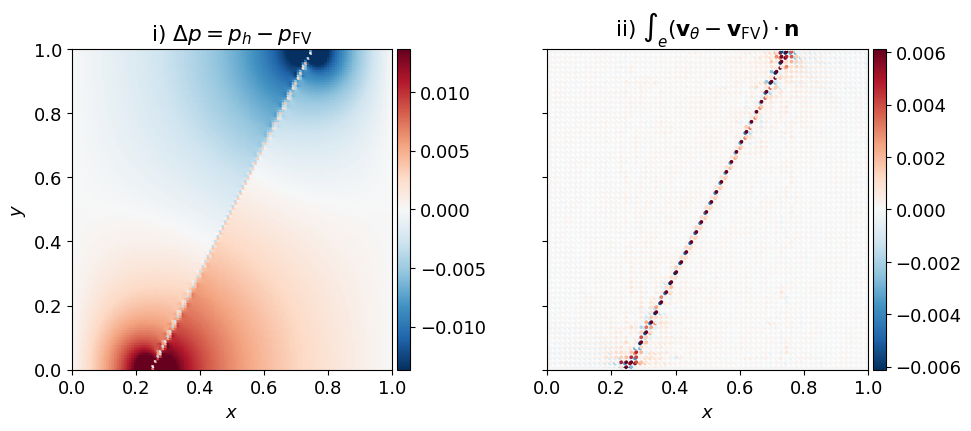

saved: result_km_case1_hardcurl_nlr/fig_km_mrst_validation.png


In [27]:

# ============================================================
# Stage 5: exact MRST-to-dual aggregation and validation
# ============================================================
from scipy.io import loadmat

MRST_CASE3_PATH = pathlib.Path("case3_ecmor/case3_mrst_export_noflow_v2.mat")
if not MRST_CASE3_PATH.exists():
    MRST_CASE3_PATH = pathlib.Path(
        "fenicsx/code/fracture problem/case3_ecmor/case3_mrst_export_noflow_v2.mat"
    )
if not MRST_CASE3_PATH.exists():
    raise FileNotFoundError("case3_mrst_export_noflow_v2.mat was not found")
mrst = loadmat(MRST_CASE3_PATH, squeeze_me=True)

_required_mrst = [
    "xc_matrix", "p_matrix", "xc_frac", "s_frac", "p_frac",
    "face_p1", "face_p2", "face_centroid", "face_normal", "face_len",
    "face_flux", "face_neighbors", "nnc_mat_cell", "nnc_frac_cell",
    "nnc_flux_m2f", "nnc_s", "snap_T_abs", "sw_matrix_snaps",
]
_missing_mrst = [name for name in _required_mrst if name not in mrst]
if _missing_mrst:
    raise RuntimeError(f"MRST export is missing required fields: {_missing_mrst}")

mrst_xc_matrix = np.asarray(mrst["xc_matrix"], dtype=float)
mrst_p_matrix = np.asarray(mrst["p_matrix"], dtype=float).reshape(-1)
mrst_xc_frac = np.asarray(mrst["xc_frac"], dtype=float)
mrst_s_frac = np.asarray(mrst["s_frac"], dtype=float).reshape(-1)
mrst_p_frac = np.asarray(mrst["p_frac"], dtype=float).reshape(-1)
mrst_face_p1 = np.asarray(mrst["face_p1"], dtype=float)
mrst_face_p2 = np.asarray(mrst["face_p2"], dtype=float)
mrst_face_centroid = np.asarray(mrst["face_centroid"], dtype=float)
mrst_face_normal = np.asarray(mrst["face_normal"], dtype=float)
mrst_face_len = np.asarray(mrst["face_len"], dtype=float).reshape(-1)
mrst_face_flux = np.asarray(mrst["face_flux"], dtype=float).reshape(-1)
mrst_face_neighbors = np.asarray(mrst["face_neighbors"], dtype=np.int64)

_mrst_dims = tuple(np.asarray(mrst["meta_celldim"], dtype=int).reshape(-1)[:2])
if _mrst_dims != (128, 128):
    raise RuntimeError(f"Expected a 128x128 MRST matrix grid, got {_mrst_dims}")
if len(mrst_xc_matrix) != 128 * 128:
    raise RuntimeError("MRST matrix-cell count is inconsistent with 128x128")


def polygon_area(poly):
    poly = np.asarray(poly, dtype=float)
    return 0.5 * abs(float(
        np.dot(poly[:, 0], np.roll(poly[:, 1], -1))
        - np.dot(poly[:, 1], np.roll(poly[:, 0], -1))
    ))


def _coord_to_cv_lookup():
    lookup = {}
    for cid, xy in enumerate(problem.coords):
        key = tuple(np.rint(64.0 * np.asarray(xy)).astype(np.int64))
        if key in lookup:
            raise RuntimeError(f"duplicate dual coordinate key {key}")
        lookup[key] = int(cid)
    return lookup


_cv_lookup = _coord_to_cv_lookup()
mrst_has_dual_transport = all(name in mrst for name in (
    "xc_matrix_dual", "face_flux_dual", "face_neighbors_dual",
    "nnc_dualmat_cell", "nnc_frac_local",
    "nnc_flux_m2f_dual", "sw_matrix_dual_snaps",
))
mrst_dual_export_to_cv = None
if mrst_has_dual_transport:
    _xc_dual = np.asarray(mrst["xc_matrix_dual"], dtype=float)
    if _xc_dual.shape != (len(problem.coords), 2):
        raise RuntimeError("updated MRST dual coordinates have an unexpected shape")
    mrst_dual_export_to_cv = np.asarray([
        _cv_lookup[tuple(np.rint(64.0 * xy).astype(np.int64))]
        for xy in _xc_dual
    ], dtype=np.int32)
    if len(np.unique(mrst_dual_export_to_cv)) != len(problem.coords):
        raise RuntimeError("updated MRST dual cells do not map one-to-one to the CG dual CVs")
    print("updated MRST 65x65 dual transport export: detected")
_ix = np.floor(128.0 * mrst_xc_matrix[:, 0]).astype(np.int64)
_iy = np.floor(128.0 * mrst_xc_matrix[:, 1]).astype(np.int64)
_vi = (_ix + 1) // 2
_vj = (_iy + 1) // 2
mrst_cell_to_cv = np.asarray([
    _cv_lookup[(int(i), int(j))] for i, j in zip(_vi, _vj)
], dtype=np.int32)
_mrst_per_cv = np.bincount(mrst_cell_to_cv, minlength=len(problem.coords))
_expected_per_cv = np.asarray([
    (1 if np.isclose(x, 0.0) or np.isclose(x, 1.0) else 2)
    * (1 if np.isclose(y, 0.0) or np.isclose(y, 1.0) else 2)
    for x, y in problem.coords
], dtype=np.int32)
if not np.array_equal(_mrst_per_cv, _expected_per_cv):
    raise RuntimeError("MRST matrix cells do not form the expected 1x1/1x2/2x2 dual unions")
dual_areas = np.asarray([
    sum(polygon_area(subpoly) for subpoly in subpolys)
    for subpolys in problem.cv_polys
], dtype=float)
_area_from_mrst = _mrst_per_cv.astype(float) / (128.0 ** 2)
_area_error = float(np.max(np.abs(dual_areas - _area_from_mrst)))
if _area_error > 5.0e-15:
    raise RuntimeError(f"MRST-to-dual union area gate failed: {_area_error:.3e}")

_nnc_mat_cell = np.asarray(mrst["nnc_mat_cell"], dtype=np.int64).reshape(-1)
_nnc_q_m2f = np.asarray(mrst["nnc_flux_m2f"], dtype=float).reshape(-1)
_nnc_frac_cell = np.asarray(mrst["nnc_frac_cell"], dtype=np.int64).reshape(-1)
_nnc_s = np.asarray(mrst["nnc_s"], dtype=float).reshape(-1)
if not (
    len(_nnc_mat_cell) == len(_nnc_q_m2f)
    == len(_nnc_frac_cell) == len(_nnc_s)
):
    raise RuntimeError("MRST NNC arrays have inconsistent lengths")
if np.any(_nnc_mat_cell < 1) or np.any(_nnc_mat_cell > len(mrst_cell_to_cv)):
    raise RuntimeError("MRST NNC exchange is not resolved by valid host matrix-cell indices")
nnc_host_cv = mrst_cell_to_cv[_nnc_mat_cell - 1]

mrst_aggregation_gate = {
    "passed": True,
    "mrst_grid": [128, 128],
    "dual_grid": [65, 65],
    "matrix_cells_assigned_once": int(len(mrst_cell_to_cv)),
    "max_union_area_error": _area_error,
    "union_count_histogram": {
        str(k): int(np.count_nonzero(_mrst_per_cv == k)) for k in (1, 2, 4)
    },
    "nnc_connections": int(len(_nnc_mat_cell)),
    "nnc_resolution": "per matrix cell (direct nnc_mat_cell mapping)",
}
print("MRST exact aggregation gate: PASS")
print(json.dumps(mrst_aggregation_gate, indent=2))


def _face_group_key(fid):
    return (
        int(problem.owner[fid]), int(problem.neighbor[fid]),
        int(problem.host_cell[fid]),
        tuple(np.rint(1.0e12 * problem.normals[fid]).astype(np.int64)),
    )


def build_dual_face_groups():
    groups = {}
    for fid in range(len(problem.owner)):
        groups.setdefault(_face_group_key(fid), []).append(int(fid))
    records = []
    for key, ids in groups.items():
        ids = np.asarray(ids, dtype=np.int32)
        normal = np.asarray(problem.normals[ids[0]], dtype=float)
        tangent = np.array([-normal[1], normal[0]], dtype=float)
        endpoints = np.vstack((problem.p0[ids], problem.p1[ids]))
        projection = endpoints @ tangent
        p0 = endpoints[int(np.argmin(projection))]
        p1 = endpoints[int(np.argmax(projection))]
        span = float(np.linalg.norm(p1 - p0))
        pieces = float(np.sum(np.linalg.norm(problem.p1[ids] - problem.p0[ids], axis=1)))
        if abs(span - pieces) > 2.0e-13:
            raise RuntimeError("split dual-face pieces did not recombine into one segment")
        records.append({
            "piece_ids": ids, "owner": key[0], "neighbor": key[1],
            "host_cell": key[2], "normal": normal,
            "p0": p0.copy(), "p1": p1.copy(), "length": span,
            "centroid": 0.5 * (p0 + p1),
        })
    return records


dual_face_groups = build_dual_face_groups()


def _segment_key(a, b):
    ia = tuple(np.rint(128.0 * np.asarray(a)).astype(np.int64))
    ib = tuple(np.rint(128.0 * np.asarray(b)).astype(np.int64))
    return tuple(sorted((ia, ib)))


_mrst_face_by_segment = {}
for fid, (a, b) in enumerate(zip(mrst_face_p1, mrst_face_p2)):
    key = _segment_key(a, b)
    if key in _mrst_face_by_segment:
        raise RuntimeError(f"duplicate MRST matrix face segment {key}")
    _mrst_face_by_segment[key] = int(fid)

dual_group_mrst_fid = np.empty(len(dual_face_groups), dtype=np.int32)
dual_group_mrst_flux = np.empty(len(dual_face_groups), dtype=float)
for gid, group in enumerate(dual_face_groups):
    key = _segment_key(group["p0"], group["p1"])
    if key not in _mrst_face_by_segment:
        raise RuntimeError(f"dual face is not an exact exported MRST face: {key}")
    fid = _mrst_face_by_segment[key]
    if abs(group["length"] - mrst_face_len[fid]) > 2.0e-13:
        raise RuntimeError("dual/MRST face lengths differ")
    sign = float(np.sign(np.dot(group["normal"], mrst_face_normal[fid])))
    if sign == 0.0:
        raise RuntimeError("dual and MRST face normals are orthogonal")
    dual_group_mrst_fid[gid] = fid
    dual_group_mrst_flux[gid] = sign * mrst_face_flux[fid]

_face_use = np.bincount(dual_group_mrst_fid, minlength=len(mrst_face_flux))
_ip1 = np.rint(128.0 * mrst_face_p1).astype(np.int64)
_ip2 = np.rint(128.0 * mrst_face_p2).astype(np.int64)
_vertical = _ip1[:, 0] == _ip2[:, 0]
_gridline_index = np.where(_vertical, _ip1[:, 0], _ip1[:, 1])
_is_physical_boundary = np.any(mrst_face_neighbors == 0, axis=1)
_lies_on_dual_boundary = _is_physical_boundary | ((_gridline_index % 2) == 1)
_expected_face_use = _lies_on_dual_boundary.astype(np.int64)
if not np.array_equal(_face_use, _expected_face_use):
    raise RuntimeError(
        "MRST faces were not used exactly once on dual boundaries and zero "
        "times inside dual-CV unions"
    )


def aggregate_piece_flux(piece_flux):
    piece_flux = np.asarray(piece_flux, dtype=float)
    return np.asarray([
        float(np.sum(piece_flux[group["piece_ids"]])) for group in dual_face_groups
    ])


dual_group_flux = {
    "CG": aggregate_piece_flux(problem.cg_face),
    "NLR": aggregate_piece_flux(nlr_face),
    "PINN": aggregate_piece_flux(option_a["face_flux"]),
    "MRST": dual_group_mrst_flux.copy(),
}

# Updated-export coincidence gate: compare maximal 65x65 CV faces.  The
# CG geometry retains a harmless host-cell split at some collinear face
# segments (notably on the physical boundary), whereas the updated MRST
# export stores each maximal CV face once.  Merge those CG subsegments
# before checking geometry, topology, and oriented integrated flux.
mrst_updated_dual_coincidence_gate = {"available": bool(mrst_has_dual_transport)}
if mrst_has_dual_transport:
    _dp1 = np.asarray(mrst["face_p1_dual"], dtype=float)
    _dp2 = np.asarray(mrst["face_p2_dual"], dtype=float)
    _dlen = np.asarray(mrst["face_len_dual"], dtype=float).reshape(-1)
    _dnorm = np.asarray(mrst["face_normal_dual"], dtype=float)
    _dneigh = np.asarray(mrst["face_neighbors_dual"], dtype=np.int64)
    _dflux = np.asarray(mrst["face_flux_dual"], dtype=float).reshape(-1)
    _n_df = len(_dflux)
    if not all(len(array) == _n_df for array in (_dp1, _dp2, _dlen, _dnorm, _dneigh)):
        raise RuntimeError("updated MRST dual-face arrays have inconsistent lengths")
    _updated_groups_by_key = {}
    for _old_gid, _group in enumerate(dual_face_groups):
        _owner = int(_group["owner"]); _neighbor = int(_group["neighbor"])
        _normal = np.asarray(_group["normal"], dtype=float)
        _orientation = 1.0
        if _neighbor >= 0 and _owner > _neighbor:
            _owner, _neighbor = _neighbor, _owner
            _normal = -_normal
            _orientation = -1.0
        _key = (
            _owner, _neighbor,
            tuple(np.rint(1.0e12 * _normal).astype(np.int64)),
        )
        _record = _updated_groups_by_key.setdefault(_key, {
            "owner": _owner, "neighbor": _neighbor,
            "normal": _normal,
            "mrst_flux_parts": [], "endpoints": [], "piece_length": 0.0,
        })
        _record["mrst_flux_parts"].append(
            _orientation * float(dual_group_mrst_flux[_old_gid])
        )
        _record["endpoints"].extend((_group["p0"], _group["p1"]))
        _record["piece_length"] += float(_group["length"])
    _updated_dual_face_groups = []
    for _record in _updated_groups_by_key.values():
        _endpoints = np.asarray(_record.pop("endpoints"), dtype=float)
        _tangent = np.array([-_record["normal"][1], _record["normal"][0]])
        _projection = _endpoints @ _tangent
        _record["p0"] = _endpoints[int(np.argmin(_projection))]
        _record["p1"] = _endpoints[int(np.argmax(_projection))]
        _record["length"] = float(np.linalg.norm(_record["p1"] - _record["p0"]))
        if abs(_record["length"] - _record.pop("piece_length")) > 2.0e-13:
            raise RuntimeError("CG dual subsegments do not form one maximal face")
        _record["mrst_flux"] = float(np.sum(_record.pop("mrst_flux_parts")))
        _updated_dual_face_groups.append(_record)
    _export_face_by_segment = {}
    for _fid, (_a, _b) in enumerate(zip(_dp1, _dp2)):
        _key = _segment_key(_a, _b)
        if _key in _export_face_by_segment:
            raise RuntimeError(f"duplicate updated MRST dual face {_key}")
        _export_face_by_segment[_key] = int(_fid)
    _used = np.zeros(_n_df, dtype=np.int32)
    _length_error = 0.0
    _normal_error = 0.0
    _flux_error = 0.0
    _topology_mismatch = 0
    for _gid, _group in enumerate(_updated_dual_face_groups):
        _key = _segment_key(_group["p0"], _group["p1"])
        if _key not in _export_face_by_segment:
            raise RuntimeError(f"CG dual face absent from updated MRST export: {_key}")
        _fid = _export_face_by_segment[_key]
        _used[_fid] += 1
        _length_error = max(_length_error, abs(_group["length"] - _dlen[_fid]))
        _dot = float(np.dot(_group["normal"], _dnorm[_fid]))
        _normal_error = max(_normal_error, abs(1.0 - abs(_dot)))
        _oriented_export_flux = float(np.sign(_dot) * _dflux[_fid])
        _flux_error = max(
            _flux_error, abs(_oriented_export_flux - _group["mrst_flux"])
        )
        _positive = _dneigh[_fid][_dneigh[_fid] > 0] - 1
        _export_cv = sorted(int(mrst_dual_export_to_cv[i]) for i in _positive)
        _group_cv = sorted([
            int(_group["owner"]),
            *([] if _group["neighbor"] < 0 else [int(_group["neighbor"])]),
        ])
        _topology_mismatch += int(_export_cv != _group_cv)
    mrst_updated_dual_coincidence_gate = {
        "available": True,
        "passed": bool(
            len(_updated_dual_face_groups) == _n_df
            and np.all(_used == 1)
            and _length_error <= 2.0e-13
            and _normal_error <= 2.0e-13
            and _topology_mismatch == 0
            and _flux_error <= 2.0e-12
        ),
        "cg_dual_cells": int(len(problem.coords)),
        "mrst_dual_cells": int(len(mrst_dual_export_to_cv)),
        "cg_dual_faces": int(len(_updated_dual_face_groups)),
        "mrst_dual_faces": int(_n_df),
        "face_use_min": int(np.min(_used)),
        "face_use_max": int(np.max(_used)),
        "max_face_length_error": float(_length_error),
        "max_unit_normal_error": float(_normal_error),
        "topology_mismatch_count": int(_topology_mismatch),
        "max_oriented_MRST_flux_error": float(_flux_error),
    }
    print("updated MRST/CG dual-mesh coincidence gate:",
          json.dumps(mrst_updated_dual_coincidence_gate, indent=2))
    if not mrst_updated_dual_coincidence_gate["passed"]:
        raise RuntimeError("updated MRST dual mesh does not coincide with the CG dual mesh")
conservation_report["gates"]["MRST_updated_dual_coincidence"] = (
    mrst_updated_dual_coincidence_gate
)


def validation_stats(diff, ref):
    diff = np.asarray(diff, dtype=float)
    ref = np.asarray(ref, dtype=float)
    return {
        "n": int(diff.size),
        "mean_abs": float(np.mean(np.abs(diff))),
        "rmse": float(np.sqrt(np.mean(diff ** 2))),
        "max_abs": float(np.max(np.abs(diff))),
        "relative_rmse": float(
            np.sqrt(np.mean(diff ** 2)) / max(np.sqrt(np.mean(ref ** 2)), 1.0e-30)
        ),
    }


p_matrix_lcg_on_mrst = eval_fem_function(p_m, mrst_xc_matrix, omega).reshape(-1)
p_matrix_diff_lcg_mrst = p_matrix_lcg_on_mrst - mrst_p_matrix
_unique_group = np.asarray([
    group["neighbor"] < 0 or group["owner"] < group["neighbor"]
    for group in dual_face_groups
], dtype=bool)
dual_flux_diff_pinn_mrst = (
    dual_group_flux["PINN"][_unique_group]
    - dual_group_flux["MRST"][_unique_group]
)
mrst_validation = {
    "pressure_LCG_minus_MRST": validation_stats(
        p_matrix_diff_lcg_mrst, mrst_p_matrix
    ),
    "dual_face_PINN_minus_aggregated_MRST": validation_stats(
        dual_flux_diff_pinn_mrst, dual_group_flux["MRST"][_unique_group]
    ),
}

from mpl_toolkits.axes_grid1 import make_axes_locatable
with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.5), constrained_layout=True)
    lim_p = max(float(np.percentile(np.abs(p_matrix_diff_lcg_mrst), 99.0)), 1.0e-14)
    sc0 = axes[0].scatter(
        mrst_xc_matrix[:, 0], mrst_xc_matrix[:, 1],
        c=p_matrix_diff_lcg_mrst, s=3, cmap="RdBu_r",
        vmin=-lim_p, vmax=lim_p, rasterized=True,
    )
    axes[0].set_title(r"i) $\Delta p=p_h-p_{\mathrm{FV}}$")
    _abs_flux_diff = np.abs(dual_flux_diff_pinn_mrst)
    lim_f = max(float(np.percentile(_abs_flux_diff, 99.5)), 1.0e-14)
    centroids = np.vstack([g["centroid"] for g in dual_face_groups])[_unique_group]
    sc1 = axes[1].scatter(
        centroids[:, 0], centroids[:, 1], c=_abs_flux_diff,
        s=3, cmap="Reds", vmin=0.0, vmax=lim_f, rasterized=True,
    )
    axes[1].set_title(
        r"ii) $|\int_e(\mathbf{v}_\theta-\mathbf{v}_{\mathrm{FV}})\cdot\mathbf{n}|$"
    )
    for ax, sc in zip(axes, (sc0, sc1)):
        ax.set_xlim(0.0, 1.0); ax.set_ylim(0.0, 1.0); ax.set_aspect("equal")
        ax.set_xlabel(r"$x$"); ax.grid(False)
        div = make_axes_locatable(ax)
        cax = div.append_axes("right", size="4%", pad=0.05)
        fig.colorbar(sc, cax=cax)
    axes[0].set_ylabel(r"$y$")
    axes[1].tick_params(labelleft=False)
    fig.savefig(OUTDIR / "fig_km_mrst_validation.png", dpi=600, bbox_inches="tight")
    plt.show()
print("saved:", OUTDIR / "fig_km_mrst_validation.png")


## Stage 6 — synchronized four-track transport

CG, NLR, PINN, and aggregated MRST are advanced on the same 65×65
vertex-centred dual grid. A single fixed time step is selected once from the
most restrictive CFL bound over all four matrix-face fields, exchange terms,
and fracture conduits. Every track is then advanced in the same loop on that
shared time grid. Water saturation equals one on the full right boundary;
both fracture tips have zero throughflow. The PINN additionally satisfies
top/bottom no-flow exactly through its streamline trace; CG and NLR retain the
weak/discrete natural-boundary traces inherited from the pressure solve.

Snapshots are recorded at exactly $T=0.10$, $0.25$, and $0.75$. The fixed CFL
step is aligned to their common time quantum, so no temporal interpolation or
track-specific final step is used. The first left-boundary saturation above
$10^{-3}$ is retained as a breakthrough diagnostic but does not stop the run.

shared transport dt=1.49700599e-04: one CFL choice over all four fields; binding=PINN, max dual-face speed=9.15439684e+00
requested snapshots: {0.1: 668, 0.25: 1670, 0.75: 5010}
  CG {'dt_matrix_raw': 0.0003421267513359054, 'dt_fracture_raw': 0.0030305982410739917, 'max_dual_face_speed': 9.112803430863877, 'dt_raw': 0.0003421267513359054}
  NLR {'dt_matrix_raw': 0.0003529238986614839, 'dt_fracture_raw': 0.0030305982410739917, 'max_dual_face_speed': 9.059623485164469, 'dt_raw': 0.0003529238986614839}
  PINN {'dt_matrix_raw': 0.0003335860305203002, 'dt_fracture_raw': 0.0030305982410739917, 'max_dual_face_speed': 9.154396838110005, 'dt_raw': 0.0003335860305203002}
  MRST {'dt_matrix_raw': 0.00042771155836855354, 'dt_fracture_raw': 0.0035039201888608937, 'max_dual_face_speed': 8.264733166910958, 'dt_raw': 0.00042771155836855354}
captured shared transport snapshot T=0.10 at step 668
captured shared transport snapshot T=0.25 at step 1670
captured shared transport snapshot T=0.75 at step 5010

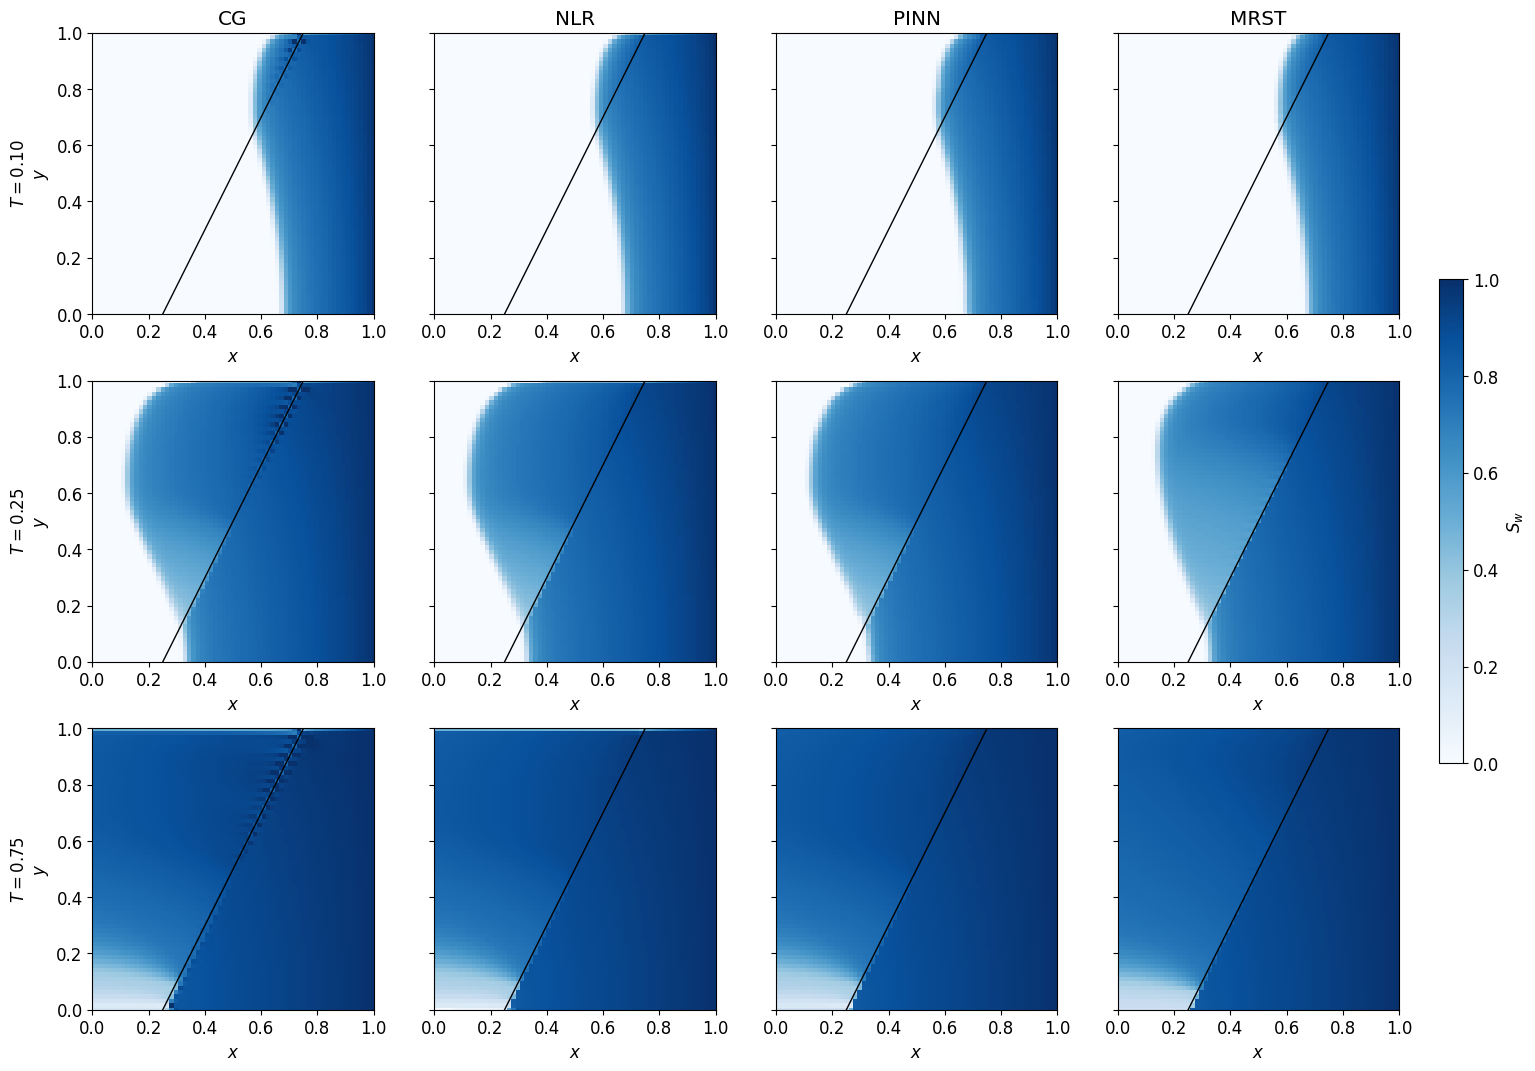

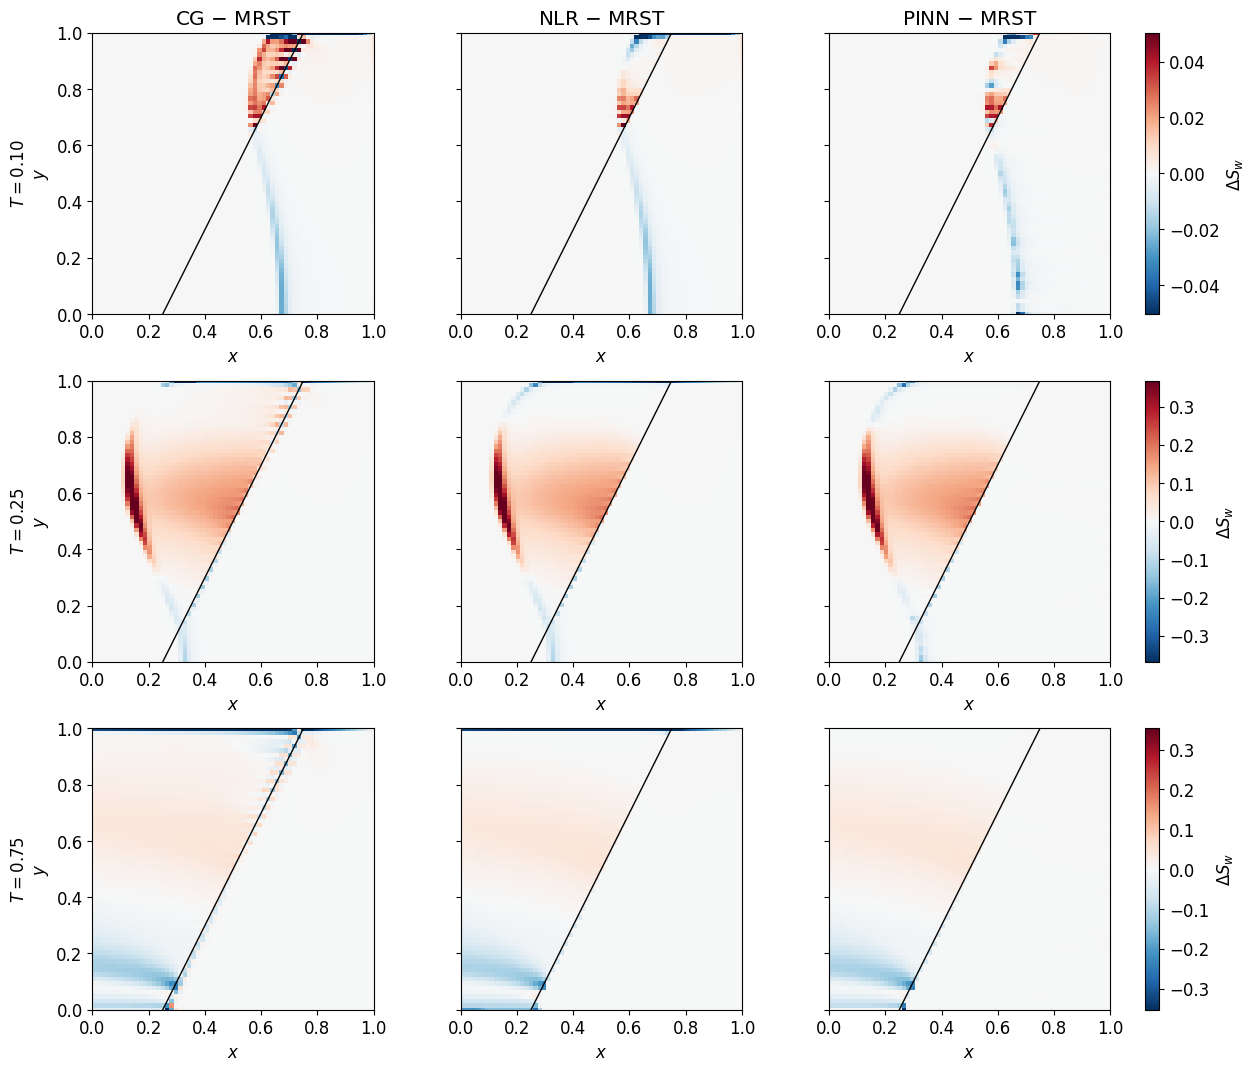

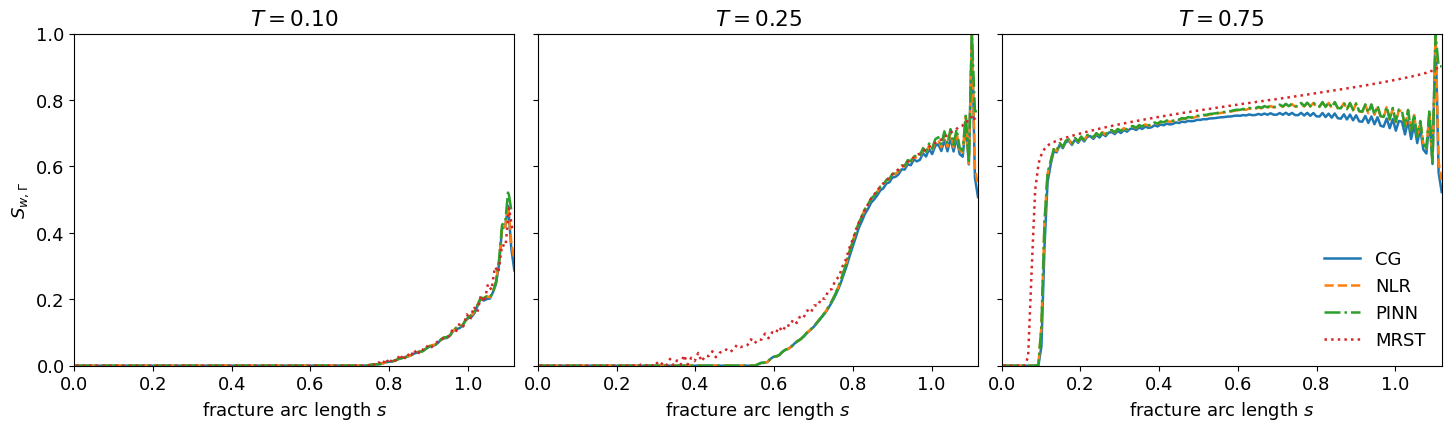

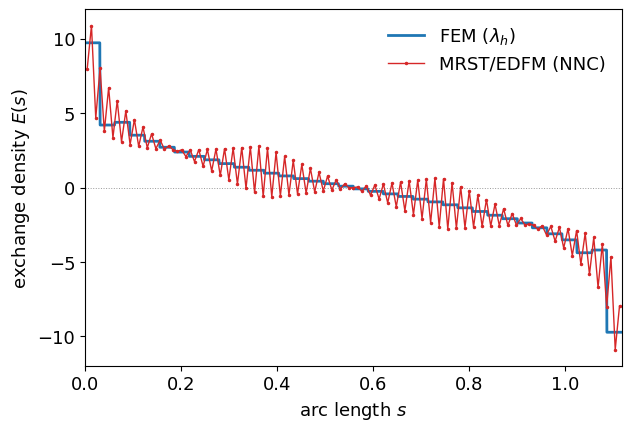

saved: result_km_case1_hardcurl_nlr/fig_km_saturation_4panel.png
saved: result_km_case1_hardcurl_nlr/fig_km_saturation_diff.png
saved: result_km_case1_hardcurl_nlr/fig_km_sgamma_profiles.png
saved: result_km_case1_hardcurl_nlr/fig_km_exchange.png
saved: result_km_case1_hardcurl_nlr/km_case1_transport.npz
saved: result_km_case1_hardcurl_nlr/km_case1_conservation.json


In [28]:

# ============================================================
# Stage 6: synchronized four-track transport on the 65x65 dual grid
# ============================================================
TRANSPORT_CFL = float(np.asarray(mrst.get("meta_CFL", 0.45)).reshape(-1)[0])
TRANSPORT_FPRIME_MAX = float(
    np.asarray(mrst.get("meta_FPRIME_MAX", 2.0)).reshape(-1)[0]
)
TRANSPORT_RIGHT_BC_S = 1.0
TRANSPORT_DEFAULT_INFLOW_S = 0.0
TRANSPORT_FRAC_POROSITY = 1.0
TRANSPORT_FRAC_TIP_S_A = 0.0
TRANSPORT_FRAC_TIP_S_B = 0.0
TRANSPORT_EXCHANGE_TOL = 1.0e-14
TRANSPORT_MAX_STEPS = 200000

def fractional_flow_bl(S):
    S = np.clip(np.asarray(S, dtype=float), 0.0, 1.0)
    return S ** 2 / (S ** 2 + (1.0 - S) ** 2 + 1.0e-30)


def pressure_driven_fracture_direction(p_A, p_B):
    # q > 0 means A -> B. Darcy flow points from high pressure to low pressure.
    dp = float(p_B) - float(p_A)
    if abs(dp) <= 1.0e-14:
        return 0.0
    return -float(np.sign(dp))


def orient_fracture_q_face(q_face, p_A, p_B, label):
    q_face = np.asarray(q_face, dtype=float).copy()
    expected = pressure_driven_fracture_direction(p_A, p_B)
    active = q_face[np.abs(q_face) > 1.0e-14]
    if expected != 0.0 and active.size:
        q_ref = float(np.median(active))
        if q_ref * expected < 0.0:
            q_face *= -1.0
            print(f"warning: flipped {label} fracture Q_face sign to match pressure-driven tip direction")
    return q_face


def fracture_direction_label(fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    if len(q) == 0:
        return "unknown"
    q_mid = float(np.median(q[np.abs(q) > 1.0e-14])) if np.any(np.abs(q) > 1.0e-14) else 0.0
    if q_mid < 0.0:
        return "B_to_A"
    if q_mid > 0.0:
        return "A_to_B"
    return "zero"


def lcg_fracture_pressure_nodes():
    pdata = build_fracture_pressure_data(gamma, V_f)
    node_to_dof = {}
    for cell in pdata["cells"]:
        for dof, sval in zip(cell["dofs"], (cell["s0"], cell["s1"])):
            node_to_dof[round(float(sval), 14)] = int(dof)
    s_nodes = np.asarray(sorted(node_to_dof), dtype=float)
    dofs = np.asarray([node_to_dof[round(float(s), 14)] for s in s_nodes], dtype=np.int32)
    return pdata, s_nodes, dofs


def build_lcg_fracture_transport_grid():
    pdata, s_nodes, dofs = lcg_fracture_pressure_nodes()
    cells = pdata["cells"]
    if len(s_nodes) != len(cells) + 1:
        raise RuntimeError("Expected a P1 fracture pressure line mesh with one more node than element.")
    p_nodes = np.asarray(p_f.x.array[dofs], dtype=float)
    # The ordered P1 nodes define the fracture elements directly.  Do not
    # recover element indices with searchsorted: cell s0 and the rounded
    # node coordinates can differ at roundoff, which previously shifted
    # elements by one index and duplicated/skipped tangential slopes.
    elem_length = np.diff(s_nodes)
    q_elem = -K_F_VALUE * np.diff(p_nodes) / elem_length

    # Node-centred dual fracture CVs: faces are the physical tips and the
    # midpoints of the pressure elements. Interior face fluxes are the element
    # two-point fluxes themselves, with no averaging across adjacent elements.
    s_faces = np.empty(len(s_nodes) + 1, dtype=float)
    s_faces[0] = s_nodes[0]
    s_faces[-1] = s_nodes[-1]
    s_faces[1:-1] = 0.5 * (s_nodes[:-1] + s_nodes[1:])
    length = np.diff(s_faces)
    q_face = np.empty(len(s_nodes) + 1, dtype=float)
    q_face[0] = 0.0  # homogeneous Neumann at fracture tip A
    q_face[1:-1] = q_elem
    q_face[-1] = 0.0  # homogeneous Neumann at fracture tip B
    q_face = orient_fracture_q_face(q_face, p_nodes[0], p_nodes[-1], "LCG")
    return {
        "kind": "lcg",
        "grid": "node_centered_dual",
        "s_faces": s_faces,
        "s_centers": s_nodes,
        "pressure_node_dofs": dofs,
        "length": length,
        "pore_volume": TRANSPORT_FRAC_POROSITY * length,
        "aperture_convention": "aperture-free node-centred dual flux and pore volume; no-flow tip faces",
        "Q_face": q_face,
        "Q_element": q_elem,
        "tip_A_flux": q_face[0],
        "tip_B_flux": -q_face[-1],
        "direction": fracture_direction_label({"Q_face": q_face}),
    }


def _mrst_fracture_edges():
    s = np.asarray(mrst_s_frac, dtype=float).reshape(-1)
    if "mrst" in globals() and "lam_seglen" in mrst:
        seg = np.asarray(mrst["lam_seglen"], dtype=float).reshape(-1)
    elif "mrst_lam_seglen" in globals():
        seg = np.asarray(mrst_lam_seglen, dtype=float).reshape(-1)
    else:
        edges = np.empty(len(s) + 1, dtype=float)
        edges[1:-1] = 0.5 * (s[:-1] + s[1:])
        edges[0] = 0.0
        edges[-1] = L_gamma
        return np.clip(edges, 0.0, L_gamma)
    return np.clip(np.r_[s[0] - 0.5 * seg[0], 0.5 * (s[:-1] + s[1:]), s[-1] + 0.5 * seg[-1]], 0.0, L_gamma)


def build_mrst_fracture_transport_grid():
    s_raw = np.asarray(mrst_s_frac, dtype=float).reshape(-1)
    p_raw = np.asarray(mrst_p_frac, dtype=float).reshape(-1)
    order = np.argsort(s_raw)
    s = s_raw[order]
    p = p_raw[order]
    edges = _mrst_fracture_edges()
    length = np.diff(edges)
    q_face = np.zeros(len(s) + 1, dtype=float)
    q_source = "pressure-gradient reconstruction"
    if "mrst" in globals() and "frac_face_flux" in mrst and "frac_face_neighbors" in mrst:
        native_q = np.asarray(mrst["frac_face_flux"], dtype=float).reshape(-1)
        native_neigh = np.asarray(mrst["frac_face_neighbors"], dtype=np.int64)
        nc = int(np.asarray(mrst.get("meta_nc", len(mrst_xc_matrix))).reshape(-1)[0])
        raw_to_sorted = np.empty(len(s_raw), dtype=np.int32)
        raw_to_sorted[order] = np.arange(len(order), dtype=np.int32)
        used = 0
        for (ga, gb), q in zip(native_neigh, native_q):
            ia = int(ga) - nc - 1
            ib = int(gb) - nc - 1
            if not (0 <= ia < len(s_raw) and 0 <= ib < len(s_raw)):
                continue
            pa = int(raw_to_sorted[ia])
            pb = int(raw_to_sorted[ib])
            if abs(pa - pb) != 1:
                raise RuntimeError("MRST fracture face neighbors are not adjacent in arc-length order.")
            face_id = max(pa, pb)
            q_face[face_id] = float(q) if s_raw[ib] > s_raw[ia] else -float(q)
            used += 1
        if used != max(len(s) - 1, 0):
            raise RuntimeError(f"Mapped {used} MRST fracture faces, expected {max(len(s) - 1, 0)}.")
        q_source = "native MRST frac_face_flux"
    else:
        Kgamma = float(np.asarray(mrst.get("meta_Kgamma", K_F_VALUE)).reshape(-1)[0]) if "mrst" in globals() else K_F_VALUE
        if len(s) > 1:
            q_face[1:-1] = -Kgamma * (p[1:] - p[:-1]) / (s[1:] - s[:-1])
    tip_flux = np.asarray(mrst.get("tip_flux", []), dtype=float).reshape(-1) if "mrst" in globals() else np.array([])
    if tip_flux.size and np.nanmax(np.abs(tip_flux)) > 1.0e-12:
        print("warning: MRST tip_flux is nonzero but ignored; this notebook enforces no-flow fracture tips.")
    q_face[0] = 0.0
    q_face[-1] = 0.0
    tip_A_flux = 0.0
    tip_B_flux = 0.0
    return {
        "kind": "mrst",
        "s_faces": edges,
        "s_centers": s,
        "length": length,
        "pore_volume": TRANSPORT_FRAC_POROSITY * length,
        "aperture_convention": f"aperture-free flux and pore volume; no-flow tip faces; {q_source}",
        "Q_face": q_face,
        "tip_A_flux": tip_A_flux,
        "tip_B_flux": tip_B_flux,
        "direction": fracture_direction_label({"Q_face": q_face}),
    }


def _split_interval_at_knots(s0, s1, knots, tol=1.0e-12):
    lo, hi = (float(s0), float(s1)) if s0 <= s1 else (float(s1), float(s0))
    if hi - lo <= tol:
        return []
    inner = np.asarray(knots, dtype=float)
    inner = inner[(inner > lo + tol) & (inner < hi - tol)]
    pts = np.sort(np.concatenate(([lo], inner, [hi])))
    keep = np.r_[True, np.diff(pts) > tol]
    pts = pts[keep]
    return list(zip(pts[:-1], pts[1:]))


def integrate_lcg_exchange_interval_to_nodes(s0, s1, fracture, sign=1.0):
    s_nodes = np.asarray(fracture["s_centers"], dtype=float)
    if len(s_nodes) < 2:
        return []
    split_knots = np.concatenate([s_nodes, _LAM_S_NODES])
    out = []
    for a, b in _split_interval_at_knots(s0, s1, split_knots):
        mid = 0.5 * (a + b)
        elem = int(np.searchsorted(s_nodes, mid, side="right") - 1)
        elem = int(np.clip(elem, 0, len(s_nodes) - 2))
        ell = float(s_nodes[elem + 1] - s_nodes[elem])
        if ell <= 0.0:
            continue
        half = 0.5 * (b - a)
        sq = mid + half * _GS2
        lam = float(sign) * lambda_h_on_s(sq)
        phi_l = (s_nodes[elem + 1] - sq) / ell
        phi_r = (sq - s_nodes[elem]) / ell
        e_l = float(half * np.sum(lam * phi_l))
        e_r = float(half * np.sum(lam * phi_r))
        if abs(e_l) > TRANSPORT_EXCHANGE_TOL:
            out.append((elem, e_l))
        if abs(e_r) > TRANSPORT_EXCHANGE_TOL:
            out.append((elem + 1, e_r))
    return out


def fracture_outflow_sum(fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    out = np.maximum(-q[:-1], 0.0) + np.maximum(q[1:], 0.0)
    if len(out):
        out[0] += np.maximum(q[0], 0.0)       # reversed A-tip inflow also tightens the explicit step.
        out[-1] += np.maximum(-q[-1], 0.0)    # B-tip inlet throughflow is an explicit boundary source.
    return out


def fracture_advection_update(S_frac, fracture):
    q = np.asarray(fracture["Q_face"], dtype=float)
    n = len(S_frac)
    update = np.zeros(n, dtype=float)
    water_in = 0.0
    water_out = 0.0
    # Left tip A: F_out = -q[0] (zero in the no-flow-tip variant).
    f_left = -q[0]
    if f_left >= 0.0:
        val = fractional_flow_bl(S_frac[0]) * f_left
        update[0] += val
        water_out += val
    else:
        val = fractional_flow_bl(TRANSPORT_FRAC_TIP_S_A) * f_left
        update[0] += val
        water_in += -val
    # Interior faces: q[j] is positive in the A -> B direction.
    if n > 1:
        q_int = q[1:-1]
        up_int = np.where(q_int >= 0.0, S_frac[:-1], S_frac[1:])
        val_int = fractional_flow_bl(up_int) * q_int
        update[:-1] += val_int
        update[1:] -= val_int
    # Right tip B: F_out = q[-1] (zero in the no-flow-tip variant).
    f_right = q[-1]
    if f_right >= 0.0:
        val = fractional_flow_bl(S_frac[-1]) * f_right
        update[-1] += val
        water_out += val
    else:
        val = fractional_flow_bl(TRANSPORT_FRAC_TIP_S_B) * f_right
        update[-1] += val
        water_in += -val
    return update, float(water_in), float(water_out)



def build_lcg_dual_exchange(fracture):
    conn_cv, conn_frac, conn_E, conn_s = [], [], [], []
    for cid, subpolys in enumerate(problem.cv_polys):
        for poly in subpolys:
            interval = hc._line_interval_in_polygon(
                np.asarray(poly), FRAC_A, tau_np, normal_np, L_gamma
            )
            if interval is None:
                continue
            s0, s1 = interval
            for frac_id, value in integrate_lcg_exchange_interval_to_nodes(
                s0, s1, fracture, sign=1.0
            ):
                conn_cv.append(int(cid)); conn_frac.append(int(frac_id))
                conn_E.append(float(value)); conn_s.append(float(fracture["s_centers"][frac_id]))
    conn_cv = np.asarray(conn_cv, dtype=np.int32)
    conn_frac = np.asarray(conn_frac, dtype=np.int32)
    conn_E = np.asarray(conn_E, dtype=float)
    e_by_cv = np.bincount(conn_cv, weights=conn_E, minlength=len(problem.coords))
    mismatch = float(np.max(np.abs(e_by_cv - problem.cv_lambda_h)))
    if mismatch > 1.0e-12:
        raise RuntimeError(f"LCG exchange-to-dual mapping failed: {mismatch:.3e}")
    return {
        "kind": "lcg_lambda_h", "conn_cv_ids": conn_cv,
        "conn_frac_ids": conn_frac, "conn_E": conn_E,
        "conn_s": np.asarray(conn_s, dtype=float), "E_by_cell": e_by_cv,
        "max_cv_integral_mismatch": mismatch,
    }


def build_mrst_dual_exchange(fracture):
    if mrst_has_dual_transport:
        dual_cell = np.asarray(mrst["nnc_dualmat_cell"], dtype=np.int64).reshape(-1)
        frac_local = np.asarray(mrst["nnc_frac_local"], dtype=np.int64).reshape(-1)
        m2f_dual = np.asarray(mrst["nnc_flux_m2f_dual"], dtype=float).reshape(-1)
        if not (len(dual_cell) == len(frac_local) == len(m2f_dual)):
            raise RuntimeError("updated MRST dual NNC arrays have inconsistent lengths")
        conn_cv = mrst_dual_export_to_cv[dual_cell - 1]
        _raw_order = np.argsort(np.asarray(mrst_s_frac, dtype=float))
        _raw_to_sorted = np.empty(len(_raw_order), dtype=np.int32)
        _raw_to_sorted[_raw_order] = np.arange(len(_raw_order), dtype=np.int32)
        conn_frac = _raw_to_sorted[frac_local - 1]
        conn_E = -m2f_dual
        e_by_cv = np.bincount(conn_cv, weights=conn_E, minlength=len(problem.coords))
        return {
            "kind": "mrst_dual_export_aggregated_nnc",
            "conn_cv_ids": conn_cv.astype(np.int32),
            "conn_frac_ids": conn_frac.astype(np.int32),
            "conn_E": conn_E,
            "conn_s": np.asarray(fracture["s_centers"])[conn_frac],
            "E_by_cell": e_by_cv,
        }
    conn_cv = nnc_host_cv.astype(np.int32, copy=True)
    conn_E = -_nnc_q_m2f.astype(float, copy=True)
    edges = np.asarray(fracture["s_faces"], dtype=float)
    conn_frac = np.searchsorted(edges, _nnc_s, side="right") - 1
    conn_frac = np.clip(conn_frac, 0, len(edges) - 2).astype(np.int32)
    e_by_cv = np.bincount(conn_cv, weights=conn_E, minlength=len(problem.coords))
    return {
        "kind": "mrst_nnc_per_host_matrix_cell", "conn_cv_ids": conn_cv,
        "conn_frac_ids": conn_frac, "conn_E": conn_E,
        "conn_s": _nnc_s.copy(), "conn_mrst_frac_cell": _nnc_frac_cell.copy(),
        "E_by_cell": e_by_cv,
    }


def group_side(group):
    if group["neighbor"] >= 0:
        return "interior"
    mid = group["centroid"]
    normal = group["normal"]
    if np.isclose(mid[0], 0.0): return "left"
    if np.isclose(mid[0], 1.0): return "right"
    if np.isclose(mid[1], 0.0): return "bottom"
    if np.isclose(mid[1], 1.0): return "top"
    raise RuntimeError(f"unclassified boundary dual face at {mid}, normal={normal}")


def oriented_track(name):
    return {
        "name": name,
        "owner": np.asarray([g["owner"] for g in dual_face_groups], dtype=np.int32),
        "neighbor": np.asarray([g["neighbor"] for g in dual_face_groups], dtype=np.int32),
        "side": np.asarray([group_side(g) for g in dual_face_groups], dtype=object),
        "p0": np.vstack([g["p0"] for g in dual_face_groups]),
        "p1": np.vstack([g["p1"] for g in dual_face_groups]),
        "length": np.asarray([g["length"] for g in dual_face_groups]),
        "F_out": dual_group_flux[name].copy(),
    }


fracture_lcg = build_lcg_fracture_transport_grid()
fracture_mrst = build_mrst_fracture_transport_grid()
exchange_lcg = build_lcg_dual_exchange(fracture_lcg)
exchange_mrst = build_mrst_dual_exchange(fracture_mrst)

# Proposition gate: the two-point fracture flux must balance the integral
# P0 multiplier load on every node-centred fracture control volume.
fracture_exchange_by_cv = np.bincount(
    exchange_lcg["conn_frac_ids"], weights=exchange_lcg["conn_E"],
    minlength=len(fracture_lcg["length"]),
)
fracture_proposition_residual = (
    np.diff(fracture_lcg["Q_face"]) + fracture_exchange_by_cv
)
fracture_proposition_gate = {
    "passed": bool(np.max(np.abs(fracture_proposition_residual)) <= 1.0e-10),
    "tolerance": 1.0e-10,
    "max_abs": float(np.max(np.abs(fracture_proposition_residual))),
    "mean_abs": float(np.mean(np.abs(fracture_proposition_residual))),
    "formula": "Q_face[j+1]-Q_face[j]+integral_Ij(lambda_h)",
}
print("fracture two-point proposition gate:", fracture_proposition_gate)
if not fracture_proposition_gate["passed"]:
    raise RuntimeError("two-point fracture flux violates the node-CV balance")
conservation_report["gates"]["fracture_two_point_transport"] = fracture_proposition_gate

tracks = {}
for name in ("CG", "NLR", "PINN", "MRST"):
    fracture = fracture_mrst if name == "MRST" else fracture_lcg
    exchange = exchange_mrst if name == "MRST" else exchange_lcg
    tracks[name] = {
        "oriented": oriented_track(name), "fracture": fracture,
        "exchange": exchange,
        "S": np.zeros(len(problem.coords), dtype=float),
        "S_frac": np.zeros(len(fracture["length"]), dtype=float),
    }


def track_raw_cfl(track):
    oriented = track["oriented"]
    exchange = track["exchange"]
    fracture = track["fracture"]
    matrix_out = np.bincount(
        oriented["owner"], weights=np.maximum(oriented["F_out"], 0.0),
        minlength=len(dual_areas),
    )
    interior = oriented["neighbor"] >= 0
    matrix_out += np.bincount(
        oriented["neighbor"][interior],
        weights=np.maximum(-oriented["F_out"][interior], 0.0),
        minlength=len(dual_areas),
    )
    matrix_out += np.bincount(
        exchange["conn_cv_ids"], weights=np.abs(exchange["conn_E"]),
        minlength=len(dual_areas),
    )
    active_m = matrix_out > 1.0e-30
    dt_m = float(np.min(dual_areas[active_m] / (TRANSPORT_FPRIME_MAX * matrix_out[active_m])))
    frac_out = fracture_outflow_sum(fracture)
    frac_out += np.bincount(
        exchange["conn_frac_ids"], weights=np.abs(exchange["conn_E"]),
        minlength=len(frac_out),
    )
    active_f = frac_out > 1.0e-30
    dt_f = float(np.min(
        fracture["pore_volume"][active_f]
        / (TRANSPORT_FPRIME_MAX * frac_out[active_f])
    )) if np.any(active_f) else np.inf
    max_face_speed = float(np.max(
        np.abs(oriented["F_out"]) / np.maximum(oriented["length"], 1.0e-30)
    ))
    return {"dt_matrix_raw": dt_m, "dt_fracture_raw": dt_f,
            "max_dual_face_speed": max_face_speed, "dt_raw": min(dt_m, dt_f)}


cfl_by_track = {name: track_raw_cfl(track) for name, track in tracks.items()}
shared_dt_cfl = TRANSPORT_CFL * min(row["dt_raw"] for row in cfl_by_track.values())
# Compare at native MRST export snapshots PVI=0.3, 0.5, and 0.7.  The
# transport driver advances in absolute time, so select the corresponding
# snap_T_abs values.  One fixed shared step is aligned with the PVI=0.1
# exported 0.1-PVI time quantum; all requested snapshots are integer multiples.
transport_snapshot_pvi = np.asarray([0.30, 0.50, 0.70], dtype=float)
mrst_export_pvi = np.asarray(mrst["snap_PVI"], dtype=float).reshape(-1)
mrst_export_times = np.asarray(mrst["snap_T_abs"], dtype=float).reshape(-1)
transport_native_indices = np.asarray([
    int(np.argmin(np.abs(mrst_export_pvi - pvi)))
    for pvi in transport_snapshot_pvi
], dtype=np.int32)
if not np.allclose(mrst_export_pvi[transport_native_indices], transport_snapshot_pvi,
                   rtol=0.0, atol=1.0e-13):
    raise RuntimeError("requested PVI values are absent from the MRST export")
transport_snapshot_times = mrst_export_times[transport_native_indices]
transport_time_quantum = float(mrst_export_times[0])
TRANSPORT_TEMPORAL_REFINEMENT = 4
steps_per_quantum = TRANSPORT_TEMPORAL_REFINEMENT * int(
    np.ceil(transport_time_quantum / shared_dt_cfl)
)
shared_dt = float(transport_time_quantum / steps_per_quantum)
snapshot_steps = np.rint(transport_snapshot_times / shared_dt).astype(np.int64)
if not np.allclose(snapshot_steps * shared_dt, transport_snapshot_times,
                   rtol=0.0, atol=5.0e-15):
    raise RuntimeError("requested transport snapshots do not lie on the shared time grid")
binding_cfl_track = min(cfl_by_track, key=lambda name: cfl_by_track[name]["dt_raw"])
global_max_face_speed = max(row["max_dual_face_speed"] for row in cfl_by_track.values())
print(
    f"shared transport dt={shared_dt:.8e}: one CFL choice over all four fields; "
    f"binding={binding_cfl_track}, max dual-face speed={global_max_face_speed:.8e}"
)
print("requested native-MRST snapshots:", {
    float(pvi): {"T_abs": float(T), "step": int(step)}
    for pvi, T, step in zip(transport_snapshot_pvi, transport_snapshot_times, snapshot_steps)
})
for name, row in cfl_by_track.items():
    print(" ", name, row)


def advance_track_one_step(track, dt):
    oriented = track["oriented"]
    owner, neighbor, F = oriented["owner"], oriented["neighbor"], oriented["F_out"]
    S, S_frac = track["S"], track["S_frac"]
    outflow = F >= 0.0
    interior_in = (~outflow) & (neighbor >= 0)
    boundary_in = (~outflow) & (neighbor < 0)
    up = np.empty_like(F)
    up[outflow] = S[owner[outflow]]
    up[interior_in] = S[neighbor[interior_in]]
    inlet = oriented["side"] == "right"
    up[boundary_in] = np.where(
        inlet[boundary_in], TRANSPORT_RIGHT_BC_S, TRANSPORT_DEFAULT_INFLOW_S
    )
    water_face_flux = fractional_flow_bl(up) * F
    matrix_update = np.bincount(owner, weights=water_face_flux, minlength=len(S))
    interior = neighbor >= 0
    matrix_update -= np.bincount(
        neighbor[interior], weights=water_face_flux[interior], minlength=len(S)
    )

    frac_update, _, _ = fracture_advection_update(S_frac, track["fracture"])
    exchange = track["exchange"]
    cv = exchange["conn_cv_ids"]
    fi = exchange["conn_frac_ids"]
    E = exchange["conn_E"]
    S_up = np.where(E > 0.0, S_frac[fi], S[cv])
    W = fractional_flow_bl(S_up) * E
    matrix_exchange = np.bincount(cv, weights=W, minlength=len(S))
    frac_exchange = np.bincount(fi, weights=-W, minlength=len(S_frac))

    S_new = S - dt * matrix_update / dual_areas + dt * matrix_exchange / dual_areas
    S_frac_new = (
        S_frac - dt * frac_update / track["fracture"]["pore_volume"]
        + dt * frac_exchange / track["fracture"]["pore_volume"]
    )
    track["S"] = np.clip(S_new, 0.0, 1.0)
    track["S_frac"] = np.clip(S_frac_new, 0.0, 1.0)


left_cv = np.isclose(problem.coords[:, 0], 0.0, atol=1.0e-14)
breakthrough_threshold = 1.0e-3
first_failed = None
snapshots = {}
step_to_snapshot = {
    int(step): float(T) for T, step in zip(transport_snapshot_times, snapshot_steps)
}
final_step = int(snapshot_steps[-1])
if final_step > TRANSPORT_MAX_STEPS:
    raise RuntimeError(
        f"final requested step {final_step} exceeds TRANSPORT_MAX_STEPS={TRANSPORT_MAX_STEPS}"
    )
for step in range(1, final_step + 1):
    for track in tracks.values():
        advance_track_one_step(track, shared_dt)
    left_max = {
        name: float(np.max(track["S"][left_cv])) for name, track in tracks.items()
    }
    if first_failed is None and any(
        value > breakthrough_threshold for value in left_max.values()
    ):
        first_failed = {"step": step, "time": step * shared_dt, "left_max": left_max}
    if step in step_to_snapshot:
        T_snapshot = step_to_snapshot[step]
        snapshots[T_snapshot] = {
            name: {"S": track["S"].copy(), "S_frac": track["S_frac"].copy()}
            for name, track in tracks.items()
        }
        _pvi = transport_snapshot_pvi[np.where(np.isclose(transport_snapshot_times, T_snapshot))[0][0]]
        print(f"captured shared transport snapshot PVI={_pvi:.2f} (T_abs={T_snapshot:.8f}) at step {step}")
if len(snapshots) != len(transport_snapshot_times):
    raise RuntimeError("one or more requested transport snapshots were not captured")

T_transport = float(transport_snapshot_times[-1])
binding_breakthrough_track = (
    max(first_failed["left_max"], key=first_failed["left_max"].get)
    if first_failed is not None else None
)
print(
    f"transport completed through T={T_transport:.2f} at shared step {final_step}; "
    f"first breakthrough-threshold crossing="
    f"{None if first_failed is None else first_failed['time']}; "
    f"binding track={binding_breakthrough_track}"
)

transport_metadata = {
    "cv_family": "65x65 vertex-centred median dual",
    "mrst_aggregation": (
        "exact summation of 128x128 matrix faces/cells; NNC exchange mapped "
        "directly by per-matrix-cell nnc_mat_cell"
    ),
    "time_grid": "every step of one shared fixed CFL dt",
    "shared_dt": shared_dt,
    "shared_dt_CFL_upper_bound": float(shared_dt_cfl),
    "time_quantum": transport_time_quantum,
    "temporal_refinement_below_CFL": TRANSPORT_TEMPORAL_REFINEMENT,
    "steps_per_time_quantum": int(steps_per_quantum),
    "CFL": TRANSPORT_CFL,
    "FPRIME_MAX": TRANSPORT_FPRIME_MAX,
    "global_max_dual_face_speed": global_max_face_speed,
    "CFL_binding_track": binding_cfl_track,
    "CFL_by_track": cfl_by_track,
    "requested_snapshot_PVI": transport_snapshot_pvi.tolist(),
    "requested_snapshot_times_abs": transport_snapshot_times.tolist(),
    "snapshot_steps": snapshot_steps.astype(int).tolist(),
    "snapshot_times_actual": (snapshot_steps * shared_dt).tolist(),
    "final_time": T_transport,
    "final_step": int(final_step),
    "breakthrough_rule": (
        "diagnostic only: first shared step at which any track has maximum "
        "left-boundary dual-CV saturation above 1e-3; transport continues "
        "through every requested snapshot"
    ),
    "threshold": breakthrough_threshold,
    "first_failed_step": first_failed,
    "binding_breakthrough_track": binding_breakthrough_track,
    "full_right_boundary_injection": True,
    "right_boundary_face_records": {
        name: int(np.count_nonzero(track["oriented"]["side"] == "right"))
        for name, track in tracks.items()
    },
}


def dual_field_grid(values):
    grid = np.full((65, 65), np.nan, dtype=float)
    for cid, (x, y) in enumerate(problem.coords):
        grid[int(round(64.0 * y)), int(round(64.0 * x))] = values[cid]
    return grid


# Native MRST saturation at the same exported PVI values.  This is the
# independent reference; the track keyed as MRST below is our shared-driver
# transport using aggregated MRST fluxes and NNC exchange.
_native_matrix = np.asarray(
    mrst["sw_matrix_dual_snaps"]
    if mrst_has_dual_transport else mrst["sw_matrix_snaps"],
    dtype=float,
)
if _native_matrix.shape[0] == len(mrst_export_times):
    _native_matrix = _native_matrix.T
if _native_matrix.shape == (len(problem.coords), len(mrst_export_times)):
    native_mrst_matrix_on_dual = np.empty(
        (len(problem.coords), len(transport_native_indices)), dtype=float
    )
    native_mrst_matrix_on_dual[mrst_dual_export_to_cv, :] = (
        _native_matrix[:, transport_native_indices]
    )
    native_mrst_reference_kind = "direct updated MRST 65x65 dual transport"
elif _native_matrix.shape == (len(mrst_cell_to_cv), len(mrst_export_times)):
    native_mrst_matrix_on_dual = np.column_stack([
        np.bincount(
            mrst_cell_to_cv, weights=_native_matrix[:, j],
            minlength=len(problem.coords),
        ) / _mrst_per_cv
        for j in transport_native_indices
    ])
    native_mrst_reference_kind = "volume-averaged legacy MRST 128x128 transport"
else:
    raise RuntimeError("native MRST matrix-saturation array has an unexpected shape")
print("MRST saturation reference:", native_mrst_reference_kind)
_native_frac = np.asarray(mrst["sw_frac_snaps"], dtype=float)
if _native_frac.shape == (len(mrst_export_times), len(mrst_s_frac)):
    _native_frac = _native_frac.T
if _native_frac.shape != (len(mrst_s_frac), len(mrst_export_times)):
    raise RuntimeError("native MRST fracture-saturation array has an unexpected shape")
_mrst_frac_order = np.argsort(mrst_s_frac)
native_mrst_frac = _native_frac[_mrst_frac_order][:, transport_native_indices]
names = ("CG", "NLR", "PINN", "MRST")
display_names = {
    "CG": "CG", "NLR": "NLR", "PINN": "PINN",
    "MRST": "MRST-flux track", "native": "MRST/EDFM",
}
publication_names = ("CG", "NLR", "PINN", "native")
xv = np.linspace(0.0, 1.0, 65)
yv = np.linspace(0.0, 1.0, 65)
with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(
        len(transport_snapshot_times), 4, figsize=(10.0, 7.8),
        constrained_layout=True, squeeze=False,
    )
    pcm = None
    for row, T_snapshot in enumerate(transport_snapshot_times):
        for col, name in enumerate(publication_names):
            ax = axes[row, col]
            pcm = ax.pcolormesh(
                xv, yv, dual_field_grid(
                    native_mrst_matrix_on_dual[:, row]
                    if name == "native" else snapshots[float(T_snapshot)][name]["S"]
                ),
                shading="nearest", cmap="Blues", vmin=0.0, vmax=1.0,
                rasterized=True,
            )
            ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.0)
            if row == 0: ax.set_title(display_names[name])
            ax.set_aspect("equal")
            ax.set_xlim(0.0, 1.0); ax.set_ylim(0.0, 1.0); ax.grid(False)
            if col == 0:
                ax.set_ylabel(rf"$T={transport_snapshot_pvi[row]:.1f}$")
            else:
                ax.tick_params(labelleft=False)
        cax = axes[row, -1].inset_axes([1.15, 0.0, 0.045, 1.0])
        cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
        cbar.ax.set_title(r"$S$", pad=7)
    fig.savefig(OUTDIR / "fig_km_saturation_native_comparison.png", dpi=300, bbox_inches="tight")
    plt.show()

diff_names = ("CG", "NLR", "PINN")
diffs = {
    float(T): {
        name: snapshots[float(T)][name]["S"] - native_mrst_matrix_on_dual[:, row]
        for name in diff_names
    }
    for row, T in enumerate(transport_snapshot_times)
}
diff_limits = {
    float(T): max(float(np.percentile(np.concatenate([
        np.abs(diffs[float(T)][name]) for name in diff_names
    ]), 99.5)), 1.0e-12)
    for T in transport_snapshot_times
}
transport_metadata["saturation_difference_color_limit"] = {
    "by_snapshot": {f"{float(T):.2f}": diff_limits[float(T)]
                    for T in transport_snapshot_times},
    "policy": (
        "one nonnegative 99.5th-percentile absolute-error limit per time, "
        "shared by CG/NLR/PINN; larger values saturate"
    ),
}
with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(
        len(transport_snapshot_times), 3, figsize=(10.0, 9.2),
        constrained_layout=True, squeeze=False,
    )
    for row, T_snapshot in enumerate(transport_snapshot_times):
        diff_lim = diff_limits[float(T_snapshot)]
        pcm = None
        for col, name in enumerate(diff_names):
            ax = axes[row, col]
            pcm = ax.pcolormesh(
                xv, yv, dual_field_grid(np.abs(diffs[float(T_snapshot)][name])),
                shading="nearest", cmap="Reds", vmin=0.0,
                vmax=diff_lim, rasterized=True,
            )
            ax.plot([FRAC_A[0], FRAC_B[0]], [FRAC_A[1], FRAC_B[1]], "k-", lw=1.0)
            if row == 0: ax.set_title(
                rf"$|$ {display_names[name]} $-$ MRST/EDFM $|$"
            )
            ax.set_aspect("equal")
            ax.set_xlim(0.0, 1.0); ax.set_ylim(0.0, 1.0); ax.grid(False)
            if col == 0:
                ax.set_ylabel(rf"$T={transport_snapshot_pvi[row]:.1f}$")
            else:
                ax.tick_params(labelleft=False)
        cax = axes[row, -1].inset_axes([1.15, 0.0, 0.045, 1.0])
        cbar = fig.colorbar(pcm, cax=cax, orientation="vertical")
        cbar.ax.set_title(r"$|\Delta S|$", pad=7)
    fig.savefig(OUTDIR / "fig_km_saturation_diff.png", dpi=300, bbox_inches="tight")
    plt.show()

styles = {
    # Marker-only CG/NLR curves remain distinguishable in grayscale.
    "CG": dict(color="C0", ls="none", marker="o", ms=3.8,
               mfc="none", mec="C0", mew=0.9, markevery=(0, 2), zorder=4),
    "NLR": dict(color="C1", ls="none", marker="x", ms=4.0,
                mew=0.9, markevery=(1, 2), zorder=4),
    "PINN": dict(color="C2", ls="-", lw=2.0, zorder=3),
    "native": dict(color="k", ls=(0, (5, 2)), lw=1.5, zorder=2),
}
with plt.rc_context({"font.size": 14}):
    fig, axes = plt.subplots(1, len(transport_snapshot_times), figsize=(10.0, 3.8),
                             sharey=True)
    for row, (ax, T_snapshot) in enumerate(zip(axes, transport_snapshot_times)):
        for name in ("CG", "NLR", "PINN"):
            fracture = tracks[name]["fracture"]
            order = np.argsort(fracture["s_centers"])
            ax.plot(
                np.asarray(fracture["s_centers"])[order],
                snapshots[float(T_snapshot)][name]["S_frac"][order],
                label=display_names[name], **styles[name],
            )
        ax.plot(
            np.asarray(fracture_mrst["s_centers"]),
            native_mrst_frac[:, row], label=display_names["native"],
            **styles["native"],
        )
        ax.set_title(rf"$T={transport_snapshot_pvi[row]:.1f}$")
        ax.set_xlim(0.0, L_gamma); ax.set_ylim(0.0, 1.0)
        ax.set_xlabel(r"fracture arc length $s$"); ax.grid(False)
    axes[0].set_ylabel(r"$S_{\Gamma}$")
    _handles, _labels = axes[-1].get_legend_handles_labels()
    fig.legend(_handles, _labels, loc="lower center", ncol=4,
               frameon=False, bbox_to_anchor=(0.5, 0.01))
    fig.tight_layout(rect=(0.0, 0.13, 1.0, 1.0))
    fig.savefig(OUTDIR / "fig_km_sgamma_profiles.png", dpi=600, bbox_inches="tight")
    plt.show()

mrst_E_by_frac = np.bincount(
    exchange_mrst["conn_frac_ids"], weights=exchange_mrst["conn_E"],
    minlength=len(fracture_mrst["length"]),
)
mrst_E_density = mrst_E_by_frac / fracture_mrst["length"]
s_lambda = np.linspace(0.0, L_gamma, 1600)
with plt.rc_context({"font.size": 14}):
    fig, ax = plt.subplots(figsize=(5.0, 4.5), constrained_layout=True)
    ax.axhline(0.0, color="0.6", lw=0.7, ls=":")
    ax.plot(s_lambda, lambda_h_on_s(s_lambda), color="C0", lw=2.0,
            label=r"$\lambda_h$")
    order = np.argsort(fracture_mrst["s_centers"])
    ax.plot(np.asarray(fracture_mrst["s_centers"])[order], mrst_E_density[order],
            color="C3", lw=1.0, marker=".", ms=3,
            label="MRST/EDFM (NNC)")
    ax.set_xlim(0.0, L_gamma); ax.set_xlabel(r"arc length $s$")
    ax.set_ylabel("fracture-matrix exchange"); ax.legend(frameon=False); ax.grid(False)
    fig.savefig(OUTDIR / "fig_km_exchange.png", dpi=600, bbox_inches="tight")
    plt.show()

np.savez_compressed(
    OUTDIR / "km_case1_transport.npz",
    names=np.asarray(names), T=transport_snapshot_times, PVI=transport_snapshot_pvi, dt=shared_dt,
    snapshot_steps=snapshot_steps,
    S_matrix=np.stack([
        np.vstack([snapshots[float(T)][name]["S"] for name in names])
        for T in transport_snapshot_times
    ]),
    S_matrix_final=np.vstack([tracks[name]["S"] for name in names]),
    S_frac_CG=np.stack([
        snapshots[float(T)]["CG"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_NLR=np.stack([
        snapshots[float(T)]["NLR"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_PINN=np.stack([
        snapshots[float(T)]["PINN"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_MRST=np.stack([
        snapshots[float(T)]["MRST"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_matrix_MRST_native=native_mrst_matrix_on_dual.T,
    S_frac_MRST_native=native_mrst_frac.T,
    s_frac_LCG=fracture_lcg["s_centers"], s_frac_MRST=fracture_mrst["s_centers"],
    dual_coords=problem.coords, dual_areas=dual_areas,
)
conservation_report["MRST_aggregation"] = mrst_aggregation_gate
conservation_report["MRST_validation"] = mrst_validation
conservation_report["transport"] = transport_metadata
(OUTDIR / "km_case1_conservation.json").write_text(
    json.dumps(json_clean(conservation_report), indent=2, allow_nan=False) + "\n"
)
for filename in (
    "fig_km_saturation_native_comparison.png", "fig_km_saturation_diff.png",
    "fig_km_sgamma_profiles.png", "fig_km_exchange.png",
    "km_case1_transport.npz", "km_case1_conservation.json",
):
    print("saved:", OUTDIR / filename)


## Stage 7 — temporal and MRST end-to-end validation

The first cell repeats the PINN transport to the first displayed snapshot with
$dt/2$ and compares that change with the simultaneous between-track differences.
The second comparison advances the aggregated-MRST flux/exchange track to every
native `snap_T_abs` time and compares it with exact volume averages of
`sw_matrix_snaps` on the 65×65 dual grid. These are independent of the static
geometry and face-flux aggregation gates.

In [29]:

# ============================================================
# Stage 7a: dt-halving sanity check on the PINN track
# ============================================================
def fresh_track(template):
    return {
        "oriented": template["oriented"],
        "fracture": template["fracture"],
        "exchange": template["exchange"],
        "S": np.zeros_like(template["S"]),
        "S_frac": np.zeros_like(template["S_frac"]),
    }


def advance_track_to_times(template, requested_times, nominal_dt):
    track = fresh_track(template)
    states = {}
    current_time = 0.0
    for target_time in np.asarray(requested_times, dtype=float):
        if target_time < current_time - 1.0e-14:
            raise ValueError("transport validation times must be increasing")
        while current_time + nominal_dt < target_time - 5.0e-15:
            advance_track_one_step(track, nominal_dt)
            current_time += nominal_dt
        remainder = target_time - current_time
        if remainder > 5.0e-15:
            advance_track_one_step(track, remainder)
            current_time = float(target_time)
        states[float(target_time)] = {
            "S": track["S"].copy(), "S_frac": track["S_frac"].copy()
        }
    return states


first_snapshot = float(transport_snapshot_times[0])
pinn_half_states = advance_track_to_times(
    tracks["PINN"], [first_snapshot], 0.5 * shared_dt
)
pinn_dt = snapshots[first_snapshot]["PINN"]["S"]
pinn_dt2 = pinn_half_states[first_snapshot]["S"]
dt_half_difference = pinn_dt2 - pinn_dt
dt_half_rmse = float(np.sqrt(np.mean(dt_half_difference ** 2)))
dt_half_max = float(np.max(np.abs(dt_half_difference)))
between_track_rmse = {
    name: float(np.sqrt(np.mean(
        (pinn_dt - snapshots[first_snapshot][name]["S"]) ** 2
    )))
    for name in ("CG", "NLR", "MRST")
}
between_scale = min(value for value in between_track_rmse.values() if value > 1.0e-15)
dt_half_ratio = dt_half_rmse / between_scale
dt_halving_validation = {
    "passed": bool(dt_half_ratio <= 0.15),
    "track": "PINN",
    "snapshot_time": first_snapshot,
    "dt": shared_dt,
    "dt_half": 0.5 * shared_dt,
    "saturation_rmse": dt_half_rmse,
    "saturation_max_abs": dt_half_max,
    "between_track_rmse_at_same_time": between_track_rmse,
    "ratio_to_smallest_between_track_rmse": dt_half_ratio,
    "acceptance": "dt/2 RMSE <= 15% of the smallest PINN-to-other-track RMSE",
}
print("dt-halving validation:", json.dumps(json_clean(dt_halving_validation), indent=2))
if not dt_halving_validation["passed"]:
    raise RuntimeError("PINN dt-halving sanity check failed")


# ============================================================
# Stage 7b: end-to-end validation against native MRST snapshots
# ============================================================
mrst_snapshot_times = np.asarray(mrst["snap_T_abs"], dtype=float).reshape(-1)
mrst_native_snapshots = np.asarray(
    mrst["sw_matrix_dual_snaps"]
    if mrst_has_dual_transport else mrst["sw_matrix_snaps"],
    dtype=float,
)
if mrst_native_snapshots.shape[0] == len(mrst_snapshot_times):
    mrst_native_snapshots = mrst_native_snapshots.T
if mrst_native_snapshots.shape == (len(problem.coords), len(mrst_snapshot_times)):
    mrst_native_on_dual = np.empty_like(mrst_native_snapshots)
    mrst_native_on_dual[mrst_dual_export_to_cv, :] = mrst_native_snapshots
    _mrst_validation_grid = "direct 65x65 MRST dual transport"
elif mrst_native_snapshots.shape == (len(mrst_cell_to_cv), len(mrst_snapshot_times)):
    mrst_native_on_dual = np.column_stack([
        np.bincount(
            mrst_cell_to_cv, weights=mrst_native_snapshots[:, j],
            minlength=len(problem.coords),
        ) / _mrst_per_cv
        for j in range(len(mrst_snapshot_times))
    ])
    _mrst_validation_grid = "legacy 128x128 MRST transport volume-averaged to dual"
else:
    raise RuntimeError(
        "sw_matrix snapshots are inconsistent with both MRST transport grids"
    )
mrst_aggregated_states = advance_track_to_times(
    tracks["MRST"], mrst_snapshot_times, shared_dt
)
mrst_aggregated_snapshots = np.column_stack([
    mrst_aggregated_states[float(T)]["S"] for T in mrst_snapshot_times
])
mrst_snapshot_rows = []
for j, T in enumerate(mrst_snapshot_times):
    reference = mrst_native_on_dual[:, j]
    difference = mrst_aggregated_snapshots[:, j] - reference
    rmse = float(np.sqrt(np.mean(difference ** 2)))
    mrst_snapshot_rows.append({
        "time": float(T),
        "rmse": rmse,
        "mean_abs": float(np.mean(np.abs(difference))),
        "max_abs": float(np.max(np.abs(difference))),
        "relative_rmse": float(
            rmse / max(np.sqrt(np.mean(reference ** 2)), 1.0e-30)
        ),
        "mean_saturation_aggregated_track": float(np.average(
            mrst_aggregated_snapshots[:, j], weights=dual_areas
        )),
        "mean_saturation_native_aggregated": float(np.average(
            reference, weights=dual_areas
        )),
    })
mrst_snapshot_max_rmse = max(row["rmse"] for row in mrst_snapshot_rows)
mrst_snapshot_validation = {
    "passed": bool(mrst_snapshot_max_rmse <= 0.12),
    "source": MRST_CASE3_PATH.name,
    "native_grid": _mrst_validation_grid,
    "comparison_grid": "65x65 vertex-centred dual",
    "aggregated_track_time_step": shared_dt,
    "snapshot_count": int(len(mrst_snapshot_times)),
    "max_snapshot_rmse": mrst_snapshot_max_rmse,
    "acceptance": "max saturation RMSE <= 0.12 (grid-family comparison gate)",
    "rows": mrst_snapshot_rows,
}
print(
    "native-MRST snapshot validation:",
    json.dumps(json_clean(mrst_snapshot_validation), indent=2),
)
if not mrst_snapshot_validation["passed"]:
    raise RuntimeError("aggregated-MRST end-to-end snapshot validation failed")


# Report the actual physical-boundary fluxes used by transport. The PINN row is
# expected at roundoff; left/right are intentionally not included in this gate.
horizontal_boundary_transport_flux = {}
for name in names:
    oriented = tracks[name]["oriented"]
    mask = (oriented["side"] == "bottom") | (oriented["side"] == "top")
    values = oriented["F_out"][mask]
    horizontal_boundary_transport_flux[name] = {
        "n": int(np.count_nonzero(mask)),
        "mean_abs": float(np.mean(np.abs(values))),
        "max_abs": float(np.max(np.abs(values))),
        "net": float(np.sum(values)),
    }
if horizontal_boundary_transport_flux["PINN"]["max_abs"] > 2.0e-12:
    raise RuntimeError("PINN hard no-flow boundary flux is above roundoff tolerance")

transport_metadata["dt_halving_validation"] = dt_halving_validation
transport_metadata["MRST_native_snapshot_validation"] = mrst_snapshot_validation
transport_metadata["horizontal_boundary_flux"] = horizontal_boundary_transport_flux
transport_metadata["method_boundary_conditions"] = {
    "PINN": "exact top/bottom no-flow by prescribed streamline trace",
    "CG": "weak natural no-flow boundary condition",
    "NLR": "inherits/reconstructs CG data without a hard boundary trace",
    "MRST": "native finite-volume no-flow boundary",
    "left_right": "unconstrained flux for every reconstruction; pressure Dirichlet",
}
conservation_report["transport"] = transport_metadata

# Rewrite the archive once, now including both validation data sets.
np.savez_compressed(
    OUTDIR / "km_case1_transport.npz",
    names=np.asarray(names), T=transport_snapshot_times, PVI=transport_snapshot_pvi, dt=shared_dt,
    snapshot_steps=snapshot_steps,
    S_matrix=np.stack([
        np.vstack([snapshots[float(T)][name]["S"] for name in names])
        for T in transport_snapshot_times
    ]),
    S_matrix_final=np.vstack([tracks[name]["S"] for name in names]),
    S_frac_CG=np.stack([
        snapshots[float(T)]["CG"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_NLR=np.stack([
        snapshots[float(T)]["NLR"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_PINN=np.stack([
        snapshots[float(T)]["PINN"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_frac_MRST=np.stack([
        snapshots[float(T)]["MRST"]["S_frac"] for T in transport_snapshot_times
    ]),
    S_matrix_MRST_native=native_mrst_matrix_on_dual.T,
    S_frac_MRST_native=native_mrst_frac.T,
    s_frac_LCG=fracture_lcg["s_centers"], s_frac_MRST=fracture_mrst["s_centers"],
    dual_coords=problem.coords, dual_areas=dual_areas,
    S_PINN_dt_half_first=pinn_dt2,
    mrst_validation_times=mrst_snapshot_times,
    S_MRST_aggregated_track_snaps=mrst_aggregated_snapshots,
    S_MRST_native_aggregated_snaps=mrst_native_on_dual,
)
(OUTDIR / "km_case1_conservation.json").write_text(
    json.dumps(json_clean(conservation_report), indent=2, allow_nan=False) + "\n"
)
print("horizontal-boundary transport flux:", json.dumps(
    json_clean(horizontal_boundary_transport_flux), indent=2
))
print("saved validated transport archive and JSON")


dt-halving validation: {
  "passed": true,
  "track": "PINN",
  "snapshot_time": 0.1,
  "dt": 0.0001497005988023952,
  "dt_half": 7.48502994011976e-05,
  "saturation_rmse": 0.0007208393162356506,
  "saturation_max_abs": 0.0063779935123864095,
  "between_track_rmse_at_same_time": {
    "CG": 0.01352048817881032,
    "NLR": 0.016124213081310734,
    "MRST": 0.005744256672843478
  },
  "ratio_to_smallest_between_track_rmse": 0.12548870241879814,
  "acceptance": "dt/2 RMSE <= 15% of the smallest PINN-to-other-track RMSE"
}
native-MRST snapshot validation: {
  "passed": true,
  "source": "case3_mrst_export_noflow_v2.mat",
  "native_grid": "128x128 MRST matrix cells",
  "comparison_grid": "65x65 vertex-centred dual; exact 1/2/4-cell volume averages",
  "aggregated_track_time_step": 0.0001497005988023952,
  "snapshot_count": 10,
  "max_snapshot_rmse": 0.042718595150731564,
  "acceptance": "max saturation RMSE <= 0.12 (grid-family comparison gate)",
  "rows": [
    {
      "time": 0.0288774038

## Stage 8 — fracture-tip transport diagnosis

This cell reports the elementwise tangential flux near tip B, the actual exchange assigned to the final fracture control volumes, and a transport rerun on the P0 multiplier panels.

In [ ]:
import importlib.util
_diag_path = pathlib.Path("fenicsx/code/fracture problem/km_case1_transport_tip_diagnostics.py")
if not _diag_path.exists():
    _diag_path = pathlib.Path("km_case1_transport_tip_diagnostics.py")
_diag_spec = importlib.util.spec_from_file_location("km_case1_transport_tip_diagnostics", _diag_path)
_diag_module = importlib.util.module_from_spec(_diag_spec)
_diag_spec.loader.exec_module(_diag_module)
tip_transport_diagnostic = _diag_module.run_tip_transport_diagnostics(globals())
